# Trusting Code - LLM Coding and Verification Example

Here we will try to construct tuning curves and link them back to cell types and connectivity. I will build up one step at a time, using Claude Code (Sonnet 4.6). I have broken down the steps for clarity in this tutorial, but they could be laid out in one long prompt such that the final goal is more clear to the LLM (but should we?). Do not stress about reading every line of the AI generated code - the goal is to illustrate and discuss verification in a more open-ended setting.

During this process, we can see that LLMs are very powerful tools, but they are not magic.



<img src="img/chat_enchanting.png" width="600">

Some of the verification methods we will use include:
- Building up from simple to more complex
- Examining dataframes
- Visualizing
- Unit tests for functions
- Testing known cases
- Synthetic data
- Computing things multiple ways
- Checking for missing / anomalous data / duplicate entries
- Focusing in on computational sections to check logic / computations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import hdmf
import pynwb
# from nwbwidgets import nwb2widget # note: nwbwidgets errors on load, requires pynbw==3.0.0
from hdmf_zarr import NWBZarrIO

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### Objective 

We are trying to generate an analysis of tuning to drifting gratings and natural stimuli in optical physiology data (2-photon imaging of GCaMP6s calcium indicator signal) from the Allen Institute V1 DeepDive data set. We would like to combine this back with inferred cell types and connectivity from the EM portion of the data set.

<img src="img/direction_tuning.png" width="900">

TODO write what this does

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DDEDE4;">

#### TODO make into questions

It read the model notebooks, looked at the directory structure, then laid out a plan. It prompted me for 

- Which stimulus type should we use: drifting_gratings_full (recommended) / drifting_gratings_windowed? 
    - I chose full

- How should we handle the calcium indicator response latency (~0.5-1s lag between spiking at dF/F peak)? 
    - I chose Other: Choose an appropriate response window based on latency to peak of the data

- How should we handle multiple temporal/spatial frequencies in the tuning curve: average across all or pick preferred? 
    - I chose average across all

- Direction tuning (0-360deg) (recommended) or orientation (0-180)? 
    - I select orientation based on biological considerations


#### Step 1: Compute tuning curves

In [5]:
# TODO precompute the snr calc

drifting_gratings_full — 192 trials
  Directions (deg): [np.float64(0.0), np.float64(30.0), np.float64(60.0), np.float64(90.0), np.float64(120.0), np.float64(150.0), np.float64(180.0), np.float64(210.0), np.float64(240.0), np.float64(270.0), np.float64(300.0), np.float64(330.0)]
  TF (Hz):          [np.float64(1.0)]
  SF (cpd):         [np.float64(0.03999999910593033), np.float64(0.07999999821186066)]
  plane-0:   9 ROIs | best SNR = 0.19  (roi_id = 4)
  plane-1:  40 ROIs | best SNR = 1.57  (roi_id = 8)
  plane-2:  59 ROIs | best SNR = 5.82  (roi_id = 13)
  plane-3: 165 ROIs | best SNR = 7.96  (roi_id = 16)
  plane-4: 325 ROIs | best SNR = 2.22  (roi_id = 7)
  plane-5: 316 ROIs | best SNR = 6.48  (roi_id = 13)

→ Using ROI 16 (plane-3, SNR = 7.96)
PSTH peak latency : 1.26 s after onset
Response window   : [0.76 – 1.76] s relative to onset
Missing responses : 0 / 192

Orientation tuning table:
 orientation  mean_response      sem  n_trials
           0      -0.237577 0.157097        29


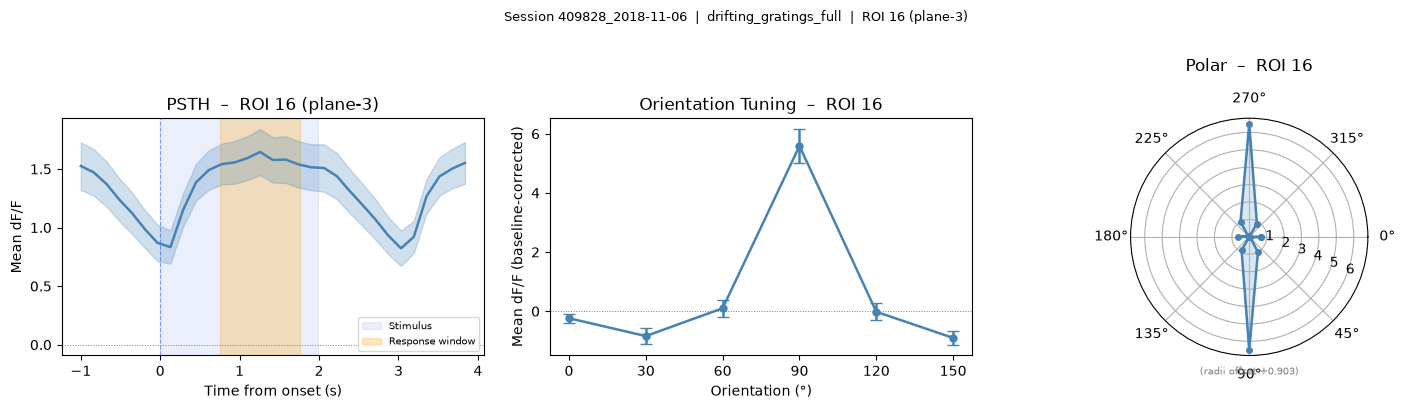

In [2]:
# GENERATED CODE

# === Step 1: Orientation Tuning Curve ===
# Session:  409828_2018-11-06_14-02-59
# Stimulus: drifting_gratings_full
# Response: mean dF/F in a data-driven window centered on the PSTH peak, baseline-corrected
# TF / SF:  averaged across all conditions
# Output:   orientation tuning curve (direction % 180 collapses opposite directions)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from hdmf_zarr import NWBZarrIO
from pathlib import Path

# ── 1. Load NWB file ──────────────────────────────────────────────────────────
session_name = '409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00'
nwb_filename = '409828_2018-11-06_14-02-59.nwb.zarr'
nwb_path     = str(Path('/data/409828_V1DD_Filtered') / session_name / nwb_filename)

io      = NWBZarrIO(nwb_path, mode='r')
nwbfile = io.read()

# ── 2. Extract epoch and stimulus tables ──────────────────────────────────────
# epoch_table: one row per stimulus block (stim_name, start_time, stop_time)
# stim_table:  one row per individual trial (start_time, stop_time, direction, TF, SF, ...)
epoch_table = nwbfile.intervals['epochs'].to_dataframe()
stim_table  = nwbfile.intervals['stimulus_table'].to_dataframe()

dg_stim = stim_table[stim_table['stim_name'] == 'drifting_gratings_full'].copy()
print(f"drifting_gratings_full — {len(dg_stim)} trials")
print(f"  Directions (deg): {sorted(dg_stim['direction'].dropna().unique())}")
print(f"  TF (Hz):          {sorted(dg_stim['temporal_frequency'].dropna().unique())}")
print(f"  SF (cpd):         {sorted(dg_stim['spatial_frequency'].dropna().unique())}")

# Epoch-level time spans for ROI responsiveness scoring
dg_epochs    = epoch_table[epoch_table['stim_name'] == 'drifting_gratings_full']
spont_epochs = epoch_table[epoch_table['stim_name'] == 'spontaneous']

# ── 3. Select the most responsive soma across all imaging planes ──────────────
# SNR = mean(dF/F during grating epochs) / std(dF/F during spontaneous epochs)
# Higher SNR → more grating-driven activity relative to baseline fluctuations.
best_snr      = -np.inf
best_roi_info = None

for plane_name in [f'plane-{i}' for i in range(6)]:
    try:
        dff_obj   = nwbfile.processing[plane_name]['dff']
        ts        = dff_obj.timestamps[:]   # imaging frame timestamps (s); zero = session start
        roi_table = dff_obj.rois.to_dataframe()

        # Boolean frame masks for each condition
        grating_mask = np.zeros(len(ts), dtype=bool)
        for _, row in dg_epochs.iterrows():
            grating_mask |= (ts >= row['start_time']) & (ts <= row['stop_time'])

        spont_mask = np.zeros(len(ts), dtype=bool)
        for _, row in spont_epochs.iterrows():
            spont_mask |= (ts >= row['start_time']) & (ts <= row['stop_time'])

        # Fall back to all non-grating frames if no spontaneous epoch recorded
        if not spont_mask.any():
            spont_mask = ~grating_mask
            print(f"  {plane_name}: no spontaneous epoch — using non-grating frames as baseline")

        if not grating_mask.any():
            print(f"  {plane_name}: no grating frames — skipping")
            continue

        # Load full dF/F matrix for this plane, score ROIs, then free memory
        dff_all      = dff_obj.data[:]                 # (nframes, n_rois)
        grating_mean = dff_all[grating_mask].mean(axis=0)
        spont_std    = dff_all[spont_mask].std(axis=0)
        spont_std[spont_std < 1e-6] = 1e-6            # guard against /0
        snr          = grating_mean / spont_std
        best_idx     = int(np.argmax(snr))
        del dff_all                                    # release memory before next plane

        roi_id_best = int(roi_table.iloc[best_idx]['roi'])
        print(f"  {plane_name}: {len(roi_table):3d} ROIs | "
              f"best SNR = {snr[best_idx]:.2f}  (roi_id = {roi_id_best})")

        if snr[best_idx] > best_snr:
            best_snr      = float(snr[best_idx])
            best_roi_info = dict(
                plane      = plane_name,
                array_idx  = best_idx,
                roi_id     = roi_id_best,
                snr        = best_snr,
                timestamps = ts,
            )

    except Exception as e:
        print(f"  {plane_name}: {e}")

print(f"\n→ Using ROI {best_roi_info['roi_id']} "
      f"({best_roi_info['plane']}, SNR = {best_roi_info['snr']:.2f})")

# ── 4. Load single-ROI dF/F trace ────────────────────────────────────────────
dff_obj_sel = nwbfile.processing[best_roi_info['plane']]['dff']
roi_dff     = np.array(dff_obj_sel.data[:, best_roi_info['array_idx']])  # (nframes,)
timestamps  = best_roi_info['timestamps']

# ── 5. Build average PSTH → determine data-driven response window ─────────────
# Align every trial to its onset, interpolate to a common time grid, then average.
# The window is placed at ±0.5 s around the PSTH peak, which automatically
# absorbs the ~0.5–1 s calcium indicator lag.
stim_dur = float((dg_stim['stop_time'] - dg_stim['start_time']).median())
pre_win  = 1.0   # s of pre-stimulus context (for display and baseline)
post_win = 2.0   # s after offset to capture GCaMP decay

dt     = float(np.median(np.diff(timestamps)))         # inter-frame interval (s)
t_grid = np.arange(-pre_win, stim_dur + post_win, dt)  # common time axis

psth_matrix = np.full((len(dg_stim), len(t_grid)), np.nan)
for i, (_, row) in enumerate(dg_stim.iterrows()):
    onset  = row['start_time']
    t_rel  = timestamps - onset
    in_win = (t_rel >= -pre_win) & (t_rel <= stim_dur + post_win)
    idx    = np.where(in_win)[0]
    if len(idx) < 2:
        continue
    # Interpolate to common grid so misaligned frames can be averaged across trials
    psth_matrix[i] = np.interp(t_grid, t_rel[idx], roi_dff[idx])

mean_psth = np.nanmean(psth_matrix, axis=0)
sem_psth  = (np.nanstd(psth_matrix, axis=0)
             / np.sqrt(np.sum(~np.isnan(psth_matrix), axis=0).clip(1)))

# Locate peak within [0, stim_dur + 1 s] (the extra 1 s allows for calcium lag)
in_stim    = (t_grid >= 0) & (t_grid <= stim_dur + 1.0)
peak_lat   = float(t_grid[in_stim][np.argmax(mean_psth[in_stim])])
half_win   = 0.5
resp_start = max(0.0,            peak_lat - half_win)
resp_end   = min(stim_dur + 1.0, peak_lat + half_win)

print(f"PSTH peak latency : {peak_lat:.2f} s after onset")
print(f"Response window   : [{resp_start:.2f} – {resp_end:.2f}] s relative to onset")

# ── 6. Compute per-trial responses (window mean minus pre-stim baseline) ──────
trial_responses = []
for _, row in dg_stim.iterrows():
    onset  = row['start_time']
    t_rel  = timestamps - onset

    # 0.5 s pre-stimulus window for baseline estimate
    base_idx = np.where((t_rel >= -0.5) & (t_rel < 0.0))[0]
    baseline = float(np.nanmean(roi_dff[base_idx])) if len(base_idx) > 0 else 0.0

    resp_idx = np.where((t_rel >= resp_start) & (t_rel <= resp_end))[0]
    if len(resp_idx) == 0:
        trial_responses.append(np.nan)
    else:
        trial_responses.append(float(np.nanmean(roi_dff[resp_idx])) - baseline)

dg_stim = dg_stim.copy()
dg_stim['response'] = trial_responses
print(f"Missing responses : {dg_stim['response'].isna().sum()} / {len(dg_stim)}")

# ── 7. Orientation tuning: collapse direction → orientation (direction % 180) ─
# Gratings moving in opposite directions (e.g. 0° and 180°) share the same
# spatial orientation.  Averaging them gives orientation selectivity rather
# than direction selectivity.  All TF and SF conditions are pooled.
dg_stim = dg_stim.dropna(subset=['direction', 'response'])
dg_stim['orientation'] = (dg_stim['direction'].round().astype(int) % 180)

tuning = (
    dg_stim.groupby('orientation')['response']
    .agg(
        mean_response = 'mean',
        sem           = lambda x: x.std(ddof=1) / np.sqrt(x.count()),
        n_trials      = 'count',
    )
    .reset_index()
)
print("\nOrientation tuning table:")
print(tuning.to_string(index=False))

# ── 8. Visualize ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 4))

# 8a — Average PSTH with response window annotated
ax1 = fig.add_subplot(1, 3, 1)
ax1.axvspan(0,          stim_dur,  alpha=0.10, color='royalblue', label='Stimulus')
ax1.axvspan(resp_start, resp_end,  alpha=0.25, color='orange',    label='Response window')
ax1.fill_between(t_grid, mean_psth - sem_psth, mean_psth + sem_psth,
                 color='steelblue', alpha=0.25)
ax1.plot(t_grid, mean_psth, color='steelblue', lw=1.8)
ax1.axvline(0, color='royalblue', ls='--', lw=0.8, alpha=0.6)
ax1.axhline(0, color='gray',      ls=':',  lw=0.7)
ax1.set_xlabel('Time from onset (s)')
ax1.set_ylabel('Mean dF/F')
ax1.set_title(f"PSTH  –  ROI {best_roi_info['roi_id']} ({best_roi_info['plane']})")
ax1.legend(fontsize=7)

# 8b — Cartesian orientation tuning curve (mean ± SEM)
ax2 = fig.add_subplot(1, 3, 2)
oris  = tuning['orientation'].values
means = tuning['mean_response'].values
sems  = tuning['sem'].values
ax2.errorbar(oris, means, yerr=sems, fmt='o-', capsize=4,
             color='steelblue', ecolor='steelblue', lw=1.8, ms=5)
ax2.axhline(0, color='gray', ls=':', lw=0.7)
ax2.set_xticks(oris)
ax2.set_xlabel('Orientation (°)')
ax2.set_ylabel('Mean dF/F (baseline-corrected)')
ax2.set_title(f"Orientation Tuning  –  ROI {best_roi_info['roi_id']}")

# 8c — Polar orientation tuning (mirrored to full 360° circle)
# The 0–180° curve is duplicated at 180–360° to give a symmetric polar display.
ax3 = fig.add_subplot(1, 3, 3, projection='polar')
angles_h   = np.deg2rad(oris)
angles_all = np.concatenate([angles_h, angles_h + np.pi])
resp_all   = np.tile(means, 2)
loop_ang   = np.append(angles_all, angles_all[0])   # close the loop
loop_resp  = np.append(resp_all,   resp_all[0])
# Shift so all polar radii >= 0 (matplotlib polar axes require non-negative radii)
offset = max(0.0, -loop_resp.min())
ax3.plot(loop_ang, loop_resp + offset, 'o-', color='steelblue', lw=1.8, ms=4)
ax3.fill(loop_ang, loop_resp + offset, alpha=0.2, color='steelblue')
ax3.set_theta_zero_location('E')   # 0 deg points East (rightward grating)
ax3.set_theta_direction(-1)        # clockwise (standard visual field convention)
ax3.set_title(f"Polar  –  ROI {best_roi_info['roi_id']}", pad=15)
if offset > 0:
    ax3.text(0.5, -0.08, f'(radii offset +{offset:.3f})',
             transform=ax3.transAxes, ha='center', fontsize=7, color='gray')

plt.suptitle(
    f"Session 409828_2018-11-06  |  drifting_gratings_full  |  "
    f"ROI {best_roi_info['roi_id']} ({best_roi_info['plane']})",
    fontsize=9, y=1.01,
)
plt.tight_layout()
plt.show()

2. Load some stuff... plot fitted tuning curve

Orientation x time plot

5 Questions

In [6]:
#TODO show snr calc code as markdown... fig code runnable

In [7]:
#TODO only use the orientation plot

In [ ]:
import pynwb

nwb = pynwb.read_nwb(nwb_path)
dff_obj_sel = nwb.processing['plane-3']['dff']
dff = dff_obj_sel.data
roi_dff     = np.array(dff_obj_sel.data[:, 16])  # (nframes,)
ts = nwb.processing['plane-3']['dff'].timestamps[:]

ROI = 16

# Visualize epochs
epochs = nwb.intervals['epochs'].to_dataframe()
names = epochs.stim_name.unique()
colors = dict(zip(names, plt.cm.tab10.colors))

def shade_epochs(ax):
    """Shade each epoch on ax, one color per stimulus name."""
    for name in names:
        stim = epochs[epochs.stim_name == name]

        for i, (start, stop) in enumerate(zip(stim.start_time, stim.stop_time)):
            ax.axvspan(start, stop,
                       color=colors[name],
                       alpha=0.3,
                       label=name if i == 0 else None)   # label only the first
    
fig, ax = plt.subplots(1, 1, figsize=(11, 3), sharex=True)

# Plot neural activity 
ax.plot(ts, dff[:, ROI], color='black')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Stimulus epochs with neural activity, ROI {ROI}')

# Add epoch shading 
shade_epochs(ax)

# Add legend 
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)


# Visualize stimulus periods
stimulus_table = nwb.intervals['stimulus_table'].to_dataframe()
drifting_gratings_full_stimulus = stimulus_table[(stimulus_table.stim_name == 'drifting_gratings_full') \
                                & (stimulus_table.start_time <= epochs[epochs.stim_name == 'drifting_gratings_full'].stop_time.values[0])]
presentations = drifting_gratings_full_stimulus 
directions = sorted(presentations.direction.dropna().unique())
colors2 = dict(zip(directions, plt.colormaps['viridis'].resampled(len(directions)).colors))

def shade_stimulus_direction(ax):
    for direction in directions:
        stim = presentations[presentations.direction == direction]

        for i, (start, stop) in enumerate(zip(stim.start_time, stim.stop_time)):
            ax.axvspan(start, stop,
                       color=colors2[direction],
                       alpha=0.3,
                       label=direction if i == 0 else None)   # label only the first

# Plot neural activity 
fig, ax = plt.subplots(1, 1, figsize=(11, 3), sharex=True)

starts = epochs[epochs.stim_name == 'drifting_gratings_full'].start_time
stops = epochs[epochs.stim_name == 'drifting_gratings_full'].stop_time
inds = np.where((ts > starts[0]) & (ts < stops[0]))[0]
ts_sub = ts[inds]
dff_sub = dff[:, ROI][inds]

ax.plot(ts_sub, dff_sub, color='black')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Stimulus directions with neural activity, ROI {ROI}')  

# Add stimulus shading 
shade_stimulus_direction(ax)
# Gaps are NaNs

# Add legend 
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)

plt.show()

In [ ]:
# Plot timecourse of individual responses - let's zoom in around 75 - 100 s

fig, ax = plt.subplots(1, 1, figsize=(11, 3), sharex=True)
ax.plot(ts_sub, dff_sub, color='black')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Stimulus directions with neural activity, ROI {ROI}') 
shade_stimulus_direction(ax)
ax.set_xlabel('Time (s)')

ax.set_xlim(75, 100)
ax.set_xticks(np.arange(75, 100 + 1, 1))

# Add legend 
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)

plt.show()

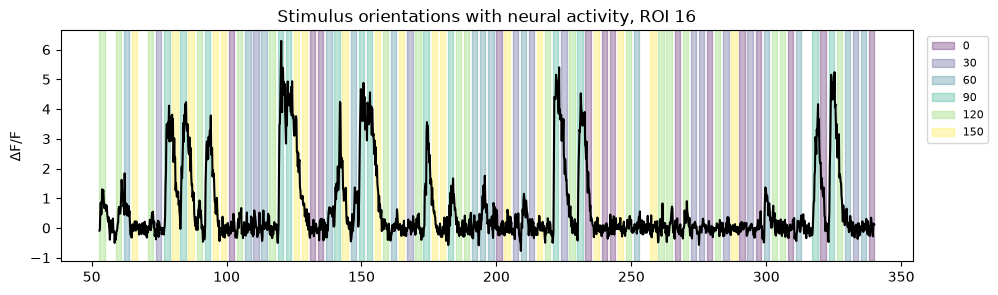

In [6]:
# Replot for orientations

presentations = presentations.dropna(subset=['direction'])
presentations['orientation'] = (presentations['direction'].round().astype(int) % 180)
orientations = sorted(presentations.orientation.dropna().unique())
colors3 = dict(zip(orientations, plt.colormaps['viridis'].resampled(len(orientations)).colors))

def shade_stimulus_orientation(ax):
    for orientation in orientations:
        stim = presentations[presentations.orientation == orientation]

        for i, (start, stop) in enumerate(zip(stim.start_time, stim.stop_time)):
            ax.axvspan(start, stop,
                       color=colors3[orientation],
                       alpha=0.3,
                       label=orientation if i == 0 else None)   # label only the first

# Plot neural activity 
fig, ax = plt.subplots(1, 1, figsize=(11, 3), sharex=True)

starts = epochs[epochs.stim_name == 'drifting_gratings_full'].start_time
stops = epochs[epochs.stim_name == 'drifting_gratings_full'].stop_time
inds = np.where((ts > starts[0]) & (ts < stops[0]))[0]
ts_sub = ts[inds]
dff_sub = dff[:, ROI][inds]

ax.plot(ts_sub, dff_sub, color='black')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Stimulus orientations with neural activity, ROI {ROI}')  

# Add stimulus shading 
shade_stimulus_orientation(ax)
# Gaps are NaNs

# Add legend 
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)

plt.show()

Verification Questions:

1. How is the data being loaded?
2. How does the code select the most responsive neuron to drifting gratings?
3. Is the selected ROI plausibly robustly responsive, and does the tuning match the given code?
4. How is the code selecting a response window? How is it baselining? What is the timecourse of the responses? What is reasonable? What do you think of the duration and shape of the response window?
5. How is the code handling missing values?
6. How are we handling multiple temporal frequencies?
7. Times are relative to what (what is zero time?) and what are time units?
9. Should we use the same response window across all data based on average behavior rather than individually for each roi? What happens if it tries to find a peak in non-responsive data?
10. Should we consider using nwb.processing['plane-0']['neuropil_corrected'] instead?

In [8]:
#TODO condense to 5 questions

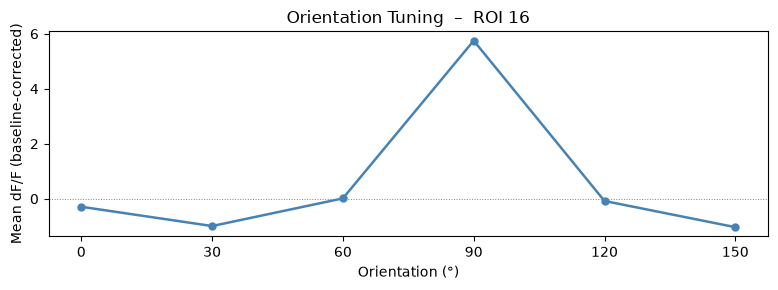

In [7]:
# Simplified code for Step 1

# ── Load data and extract epoch and stimulus tables ─────────────────────────
session_name = '409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00'
nwb_filename = '409828_2018-11-06_14-02-59.nwb.zarr'
nwb_path     = str(Path('/data/409828_V1DD_Filtered') / session_name / nwb_filename)

io      = NWBZarrIO(nwb_path, mode='r')
nwbfile = io.read()

epoch_table = nwbfile.intervals['epochs'].to_dataframe()
stim_table  = nwbfile.intervals['stimulus_table'].to_dataframe()

dg_stim = stim_table[stim_table['stim_name'] == 'drifting_gratings_full'].copy()

# ── Load single-ROI dF/F trace ────────────────────────────────────────────
roi = 16
plane = 'plane-3'
dff_obj_sel = nwbfile.processing[plane]['dff']
roi_dff     = np.array(dff_obj_sel.data[:, roi])  # (nframes,)
timestamps  = nwbfile.processing['plane-3']['dff'].timestamps[:]

# ── Compute per-trial responses (window mean minus pre-stim baseline) ──────
resp_start = 0.7
resp_end  = 2.5

trial_responses = []
for _, row in dg_stim.iterrows():
    onset  = row['start_time']
    t_rel  = timestamps - onset

    # 0.5 s pre-stimulus window for baseline estimate
    base_idx = np.where((t_rel >= -0.5) & (t_rel < 0.0))[0]
    baseline = float(np.nanmean(roi_dff[base_idx])) if len(base_idx) > 0 else 0.0

    resp_idx = np.where((t_rel >= resp_start) & (t_rel <= resp_end))[0]
    if len(resp_idx) == 0:
        trial_responses.append(np.nan)
    else:
        trial_responses.append(float(np.nanmean(roi_dff[resp_idx])) - baseline)

dg_stim['response'] = trial_responses

# ── Orientation tuning: collapse direction → orientation (direction % 180)
dg_stim = dg_stim.dropna(subset=['direction', 'response'])
dg_stim['orientation'] = (dg_stim['direction'].round().astype(int) % 180)

tuning = (
    dg_stim.groupby('orientation')['response']
    .mean()    # Just save mean for aggregating across cells
    .reset_index()
)
#print("\nOrientation tuning table:")
#print(tuning.to_string(index=False))

# ── Visualize ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1,1, figsize=(8, 3))

oris  = tuning['orientation'].values
means = tuning['response'].values
ax.plot(oris, means, 'o-',
             color='steelblue', lw=1.8, ms=5)
ax.axhline(0, color='gray', ls=':', lw=0.7)
ax.set_xticks(oris)
ax.set_xlabel('Orientation (°)')
ax.set_ylabel('Mean dF/F (baseline-corrected)')
ax.set_title(f"Orientation Tuning  –  ROI {best_roi_info['roi_id']}")

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### [Prompt]
Next,
- Now please batch this process for all the available roi's and recording sessions, based on the block "Simplified code for Step 1"
- Please report on data completeness and any missing data, as well as what rois are available across which sessions

Output format:
- Please write a code block in the section of this Jupyter notebook after "Step 2: Batch process all data"
- Save any computational output to the /scratch folder


#### Step 2: Batch process all data

<span style="color:red"> Warning: Please do not run the subsequent code to re-compute and record all the tuning curves as this can take a long time. This code has already been run for you. </span>

```python
# GENERATED CODE - DO NOT RUN

# === Step 2: Batch orientation tuning across all ROIs and all sessions ===
# Generalizes "Simplified code for Step 1" from one ROI in one session to every
# ROI in every session, and audits data completeness along the way.
#
# Four things had to change from Step 1 to be correct and survivable at scale:
#   * Step 1 used `roi = 16` as a COLUMN INDEX into the dF/F matrix. The `roi`
#     field in the ROI table is a separate global identifier -- the one used by
#     coregistration_1196.feather. Both are kept here: `roi_idx` (array column)
#     and `roi` (identifier), alongside column/volume/plane, which together form
#     the key that links back to the EM tables in Step 4.
#   * Sessions are stored in two backends (.nwb.zarr and plain .nwb/HDF5), so we
#     use pynwb.read_nwb(), which dispatches on the file type, rather than
#     NWBZarrIO, which reads only the zarr stores.
#   * Every failure (missing session, plane, stimulus, or trial) is recorded
#     rather than raised, so one bad session cannot abort the batch and the
#     completeness report reflects what actually happened.
#   * Each session is CHECKPOINTED to /scratch as soon as it finishes, so a
#     crash costs one session rather than the whole ~45 min of NWB reading.
#
# What gets checkpointed is ONE ROW PER ROI-SESSION, holding mean / sd / n for
# every orientation and every direction. Individual trials are reduced on the
# fly and not stored: mean, sd and n are sufficient statistics for everything
# Steps 3-5 need -- tuning curves, error bars, OSI/DSI, tuning width, and a
# one-way ANOVA across orientations for responsiveness gating (the between- and
# within-group sums of squares are exactly recoverable from mean/sd/n).
# Direction is kept alongside orientation because `direction % 180` is lossy and
# DSI needs it. Storing raw trials would only add bootstrap CIs, split-half
# reliability, noise correlations, and per-TF/SF re-analysis -- none of which
# these steps use. Note that changing RESP_START/RESP_END still requires
# re-reading the NWB files either way.

import json
import traceback
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pynwb

warnings.filterwarnings('ignore')

# ── Configuration (same response windows as "Simplified code for Step 1") ─────
DATA_ROOT = Path('/data/409828_V1DD_Filtered')
OUT_DIR   = Path('/scratch/v1dd_step2')
SHARD_DIR = OUT_DIR / 'shards'          # per-session checkpoints
STIM_NAME = 'drifting_gratings_full'
RESP_START, RESP_END = 0.7, 2.5    # s after trial onset
BASE_START, BASE_END = -0.5, 0.0   # s relative to trial onset
DFF_KEY    = 'dff'
MAX_PLANES = 8                     # probe plane-0 .. plane-7; only existing ones are used
RESUME     = True                  # skip sessions already checkpointed;
                                   # delete SHARD_DIR to force a full recompute

for sub in ('tuning', 'meta'):
    (SHARD_DIR / sub).mkdir(parents=True, exist_ok=True)

KEY = ['session_name', 'column', 'volume', 'plane', 'roi', 'roi_idx']


def find_nwb_path(session_dir):
    """Return the NWB store inside a session folder (zarr or HDF5), or None."""
    hits = sorted(list(session_dir.glob('*.nwb.zarr')) + list(session_dir.glob('*.nwb')))
    return hits[0] if hits else None


def trial_window_indices(timestamps, onsets, t0, t1):
    """Frame index bounds [lo, hi) covering [onset+t0, onset+t1] for each trial.

    Timestamps are monotonically increasing, so searchsorted is exact and far
    cheaper than the per-trial boolean mask used in Step 1."""
    lo = np.searchsorted(timestamps, onsets + t0, side='left')
    hi = np.searchsorted(timestamps, onsets + t1, side='right')
    return lo, hi


def window_means(dff, lo, hi):
    """Per-trial, per-ROI nanmean of dF/F over frame windows [lo, hi).

    Returns (n_trials, n_rois); NaN where a trial had no frames or only NaNs."""
    out = np.full((len(lo), dff.shape[1]), np.nan)
    for i in range(len(lo)):
        if hi[i] > lo[i]:
            seg = dff[lo[i]:hi[i]]
            # An all-NaN column stays NaN -- recorded as missing, never as 0
            out[i] = np.nanmean(seg, axis=0) if np.isfinite(seg).any() else np.nan
    return out


def condition_stats(trial_resp, levels, prefix):
    """Reduce (n_trials, n_rois) responses to mean/sd/n per stimulus level.

    Returns a dict of column name -> length-n_rois array, so each ROI ends up as
    a single row. `levels` is the per-trial stimulus value (orientation or
    direction); trials are pooled across TF and SF, as chosen in Step 1."""
    cols = {}
    for lev in np.unique(levels):
        sel = trial_resp[levels == lev]                      # (n_repeats, n_rois)
        n = np.isfinite(sel).sum(axis=0)
        with np.errstate(invalid='ignore'):
            cols[f'{prefix}_mean_{lev:g}'] = np.nanmean(sel, axis=0)
            # ddof=1 is undefined for n<2; leave those as NaN rather than 0
            cols[f'{prefix}_sd_{lev:g}'] = np.where(n > 1, np.nanstd(sel, axis=0, ddof=1), np.nan)
        cols[f'{prefix}_n_{lev:g}'] = n
    return cols


def checkpoint(session_name, rec, tuning_part):
    """Persist one session's results so a later crash cannot cost this work."""
    if tuning_part is not None and len(tuning_part):
        tuning_part.to_parquet(SHARD_DIR / 'tuning' / f'{session_name}.parquet', index=False)
    # meta is written LAST and is what RESUME tests, so a partial write is retried
    (SHARD_DIR / 'meta' / f'{session_name}.json').write_text(json.dumps(rec, default=str))


# ── Main loop over sessions ───────────────────────────────────────────────────
session_dirs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(session_dirs)} session folders under {DATA_ROOT}\n")

for s_i, session_dir in enumerate(session_dirs):
    session_name = session_dir.name
    meta_path = SHARD_DIR / 'meta' / f'{session_name}.json'
    print(f"[{s_i + 1:2d}/{len(session_dirs)}] {session_name}")

    if RESUME and meta_path.exists():
        print("    (checkpoint exists -- skipping)")
        continue

    rec = dict(session_name=session_name)
    session_issues = []

    nwb_path = find_nwb_path(session_dir)
    if nwb_path is None:
        rec.update(status='no_nwb_file', n_planes=0, n_rois=0, n_dg_trials=0,
                   issues=[f"{session_name}: no .nwb or .nwb.zarr found"])
        checkpoint(session_name, rec, None)
        print("    !! no NWB file")
        continue

    rec['nwb_file'] = nwb_path.name
    rec['backend']  = 'zarr' if nwb_path.name.endswith('.zarr') else 'hdf5'

    try:
        nwb = pynwb.read_nwb(str(nwb_path))
    except Exception as e:
        rec.update(status=f'read_failed: {e}', n_planes=0, n_rois=0, n_dg_trials=0,
                   issues=[f"{session_name}: read_nwb failed -- {e}"])
        checkpoint(session_name, rec, None)
        print(f"    !! read failed: {e}")
        continue

    rec['session_id'] = getattr(nwb, 'session_id', None)

    # ── Stimulus / epoch tables ───────────────────────────────────────────────
    if 'stimulus_table' not in nwb.intervals:
        rec.update(status='no_stimulus_table', n_planes=0, n_rois=0, n_dg_trials=0,
                   issues=[f"{session_name}: no stimulus_table"])
        checkpoint(session_name, rec, None)
        continue

    stim_table  = nwb.intervals['stimulus_table'].to_dataframe()
    epoch_table = (nwb.intervals['epochs'].to_dataframe()
                   if 'epochs' in nwb.intervals else pd.DataFrame())
    rec['stim_names_present'] = ';'.join(sorted(stim_table['stim_name'].dropna().unique()))
    rec['n_epochs'] = len(epoch_table)

    dg = stim_table[stim_table['stim_name'] == STIM_NAME].copy()
    rec['n_dg_trials'] = len(dg)
    if len(dg) == 0:
        rec.update(status=f'no_{STIM_NAME}', n_planes=0, n_rois=0,
                   issues=[f"{session_name}: stimulus '{STIM_NAME}' absent "
                           f"(present: {rec['stim_names_present']})"])
        checkpoint(session_name, rec, None)
        print(f"    !! no {STIM_NAME}")
        continue

    # Trials with no direction cannot contribute to an orientation curve.
    # NOTE: Step 1 printed "Missing responses: 0 / 192" BEFORE dropping these,
    # so its trial count was 192 while only 184 trials carry a direction. That
    # difference is recorded explicitly here rather than left implicit.
    rec['n_dg_trials_missing_direction'] = int(dg['direction'].isna().sum())
    dg = dg.dropna(subset=['direction']).reset_index(drop=True)
    dg['orientation'] = dg['direction'].round().astype(int) % 180

    rec['directions']           = ';'.join(str(x) for x in sorted(dg['direction'].unique()))
    rec['n_directions']         = dg['direction'].nunique()
    rec['n_orientations']       = dg['orientation'].nunique()
    rec['temporal_frequencies'] = ';'.join(str(x) for x in sorted(dg['temporal_frequency'].dropna().unique()))
    rec['spatial_frequencies']  = ';'.join(str(x) for x in sorted(dg['spatial_frequency'].dropna().unique()))
    rec['n_dg_trials_used']     = len(dg)
    rec['dg_trial_duration_s']  = float((dg['stop_time'] - dg['start_time']).median())
    rec['dg_epoch_count']       = int((epoch_table['stim_name'] == STIM_NAME).sum()) if len(epoch_table) else None

    onsets       = dg['start_time'].to_numpy(float)
    directions   = dg['direction'].to_numpy(float)
    orientations = dg['orientation'].to_numpy(int)
    n_tr         = len(dg)

    # ── Per-plane processing ──────────────────────────────────────────────────
    plane_names = [f'plane-{i}' for i in range(MAX_PLANES) if f'plane-{i}' in nwb.processing]
    rec['planes_present'] = ';'.join(plane_names)
    rec['n_planes'] = len(plane_names)
    if not plane_names:
        session_issues.append(f"{session_name}: no plane-* processing modules")

    n_rois_session = 0
    tuning_parts = []

    for plane_name in plane_names:
        try:
            module = nwb.processing[plane_name]
            if DFF_KEY not in module.data_interfaces:
                session_issues.append(f"{session_name}/{plane_name}: no '{DFF_KEY}' interface "
                                      f"(has: {sorted(module.data_interfaces)})")
                continue

            dff_obj    = module[DFF_KEY]
            timestamps = np.asarray(dff_obj.timestamps[:], dtype=float)
            dff        = np.asarray(dff_obj.data[:], dtype=float)   # (n_frames, n_rois)
            roi_tbl    = dff_obj.rois.to_dataframe().reset_index(drop=True)

            # Shape sanity: a mismatch means the ROI mapping is not trustworthy
            if dff.shape[0] != len(timestamps):
                session_issues.append(f"{session_name}/{plane_name}: dff frames {dff.shape[0]} != "
                                      f"timestamps {len(timestamps)} -- truncating to the shorter")
                n = min(dff.shape[0], len(timestamps))
                dff, timestamps = dff[:n], timestamps[:n]
            if dff.shape[1] != len(roi_tbl):
                session_issues.append(f"{session_name}/{plane_name}: dff columns {dff.shape[1]} != "
                                      f"ROI table rows {len(roi_tbl)} -- SKIPPED (ambiguous ROI mapping)")
                continue

            # Trials falling outside this plane's recorded time range are unusable
            n_out = int(((onsets + RESP_START) > timestamps[-1]).sum()
                        + ((onsets + RESP_END) < timestamps[0]).sum())
            if n_out:
                session_issues.append(f"{session_name}/{plane_name}: {n_out} {STIM_NAME} trials "
                                      f"outside the dF/F time range")

            # ── Per-trial responses: window mean minus pre-stimulus baseline ──
            r_lo, r_hi = trial_window_indices(timestamps, onsets, RESP_START, RESP_END)
            b_lo, b_hi = trial_window_indices(timestamps, onsets, BASE_START, BASE_END)
            resp = window_means(dff, r_lo, r_hi)      # (n_trials, n_rois)
            base = window_means(dff, b_lo, b_hi)
            # Step 1 substituted baseline = 0 when the pre-stimulus window was
            # empty; the same convention is kept so batch and single-ROI agree
            base = np.nan_to_num(base, nan=0.0)
            trial_resp = resp - base
            n_rois = trial_resp.shape[1]
            n_valid = np.isfinite(trial_resp).sum(axis=0)

            # ── One row per ROI: identity + QC + orientation and direction curves
            tuning_parts.append(pd.DataFrame({
                'session_name':   session_name,
                'column':         roi_tbl['column'].astype(str).values,
                'volume':         roi_tbl['volume'].astype(str).values,
                'plane':          roi_tbl['plane'].values,
                'roi':            roi_tbl['roi'].values,
                'roi_idx':        np.arange(n_rois),
                'plane_name':     plane_name,
                'is_soma':        (roi_tbl['is_soma'].values if 'is_soma' in roi_tbl else np.nan),
                'n_frames':       dff.shape[0],
                'frac_nan_dff':   np.isnan(dff).mean(axis=0),
                'n_trials_total': n_tr,
                'n_trials_valid': n_valid,
                **condition_stats(trial_resp, orientations, 'ori'),
                **condition_stats(trial_resp, directions,   'dir'),
            }))
            n_rois_session += n_rois
            print(f"    {plane_name}: {n_rois:4d} ROIs, "
                  f"{n_valid.min():3d}-{n_valid.max():3d} valid trials/ROI")

            del dff, resp, base, trial_resp

        except Exception as e:
            session_issues.append(f"{session_name}/{plane_name}: EXCEPTION {e}\n"
                                  f"{traceback.format_exc(limit=3)}")
            print(f"    !! {plane_name}: {e}")

    rec['n_rois'] = n_rois_session
    rec['status'] = 'ok' if n_rois_session > 0 else 'no_rois_processed'
    rec['issues'] = session_issues

    checkpoint(session_name, rec,
               pd.concat(tuning_parts, ignore_index=True) if tuning_parts else None)
    del tuning_parts

# ── Assemble outputs from the checkpoints ─────────────────────────────────────
metas = [json.loads(p.read_text()) for p in sorted((SHARD_DIR / 'meta').glob('*.json'))]
sessions_df = pd.DataFrame(metas).drop(columns=['issues'], errors='ignore')
all_issues = [i for m in metas for i in m.get('issues', [])]

shards = sorted((SHARD_DIR / 'tuning').glob('*.parquet'))
tuning = (pd.concat([pd.read_parquet(p) for p in shards], ignore_index=True)
          if shards else pd.DataFrame())

sessions_df.to_csv(OUT_DIR / 'session_inventory.csv', index=False)
tuning.to_parquet(OUT_DIR / 'roi_tuning.parquet', index=False)
(OUT_DIR / 'issues_log.txt').write_text('\n'.join(all_issues) if all_issues else '(none)\n')

ori_mean_cols = sorted([c for c in tuning.columns if c.startswith('ori_mean_')],
                       key=lambda c: float(c.rsplit('_', 1)[1]))
dir_mean_cols = sorted([c for c in tuning.columns if c.startswith('dir_mean_')],
                       key=lambda c: float(c.rsplit('_', 1)[1]))

# ── Completeness report ───────────────────────────────────────────────────────
lines = []
add = lines.append
add('=' * 78)
add('STEP 2 BATCH -- DATA COMPLETENESS REPORT')
add('=' * 78)
add(f"Session folders found        : {len(sessions_df)}")
add(f"Sessions processed OK        : {(sessions_df['status'] == 'ok').sum()}")
bad = sessions_df[sessions_df['status'] != 'ok']
add(f"Sessions NOT processed       : {len(bad)}")
for _, r in bad.iterrows():
    add(f"    - {r['session_name']}: {r['status']}")
add('')
add(f"Storage backends             : {sessions_df['backend'].value_counts().to_dict()}")
add(f"Rows in roi_tuning (ROI x session): {len(tuning)}")
if len(tuning):
    add(f"Distinct (col,vol,plane,roi) : {tuning[['column','volume','plane','roi']].drop_duplicates().shape[0]}")
    add(f"is_soma == True              : {int((tuning['is_soma'] == True).sum())} / {len(tuning)}")
    add(f"ROIs with any NaN in dF/F    : {int((tuning['frac_nan_dff'] > 0).sum())}")
    add(f"ROIs missing >=1 trial       : {int((tuning['n_trials_valid'] < tuning['n_trials_total']).sum())}")
    add(f"ROIs with zero valid trials  : {int((tuning['n_trials_valid'] == 0).sum())}")
    add(f"Orientation columns          : {len(ori_mean_cols)}  {ori_mean_cols}")
    add(f"Direction columns            : {len(dir_mean_cols)}")
    add(f"ROIs with any NaN in curve   : {int(tuning[ori_mean_cols].isna().any(axis=1).sum())}")
add('')
add('-' * 78)
add('PER-SESSION INVENTORY')
add('-' * 78)
add(sessions_df.reindex(columns=['session_name', 'backend', 'n_planes', 'n_rois',
                                 'n_dg_trials', 'n_dg_trials_missing_direction',
                                 'n_dg_trials_used', 'n_directions', 'n_orientations',
                                 'status']).to_string(index=False))
add('')
add('-' * 78)
add('STIMULUS CONDITIONS PER SESSION')
add('-' * 78)
add(sessions_df.reindex(columns=['session_name', 'dg_trial_duration_s',
                                 'temporal_frequencies', 'spatial_frequencies',
                                 'directions']).to_string(index=False))
add('')
add('-' * 78)
add('ROI AVAILABILITY ACROSS SESSIONS')
add('-' * 78)
if len(tuning):
    per_key = (tuning.groupby(['column', 'volume', 'plane', 'roi'])['session_name']
                     .nunique().rename('n_sessions').reset_index())
    add(f"Distinct ROI keys (column,volume,plane,roi): {len(per_key)}")
    add('Number of sessions each ROI key appears in:')
    add(per_key['n_sessions'].value_counts().sort_index().to_string())
    add('')
    # Count ROWS, not nunique('roi'): `roi` ids are only unique WITHIN a plane
    # and collide across planes of the same volume, so nunique would undercount
    # (e.g. 914 ROIs in one session share only 407 distinct roi values). This is
    # also why the Step 4 merge must join on all of column+volume+plane+roi.
    add('ROI counts by (column, volume) x session:')
    add(tuning.groupby(['column', 'volume', 'session_name'])
              .size().rename('n_rois').reset_index().to_string(index=False))
    add('')
    dup_roi = tuning.duplicated(['session_name', 'column', 'volume', 'roi']).sum()
    add(f"ROI ids that repeat within a session (across planes): {int(dup_roi)}")
    add(f"Duplicates of the full key (session,col,vol,plane,roi): "
        f"{int(tuning.duplicated(['session_name','column','volume','plane','roi']).sum())}")
add('')
add(f"Anomalies logged: {len(all_issues)}  (full text in {OUT_DIR / 'issues_log.txt'})")
for line in all_issues[:40]:
    add(f"    - {line.splitlines()[0]}")

report = '\n'.join(lines)
(OUT_DIR / 'completeness_report.txt').write_text(report)
print('\n' + report)
print(f"\nSaved outputs to {OUT_DIR}")
print(f"Per-session checkpoints in {SHARD_DIR}/tuning (re-running skips completed sessions)")
```


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DDEDE4;">

#### [Our Interaction]

It first tried to write a new notebook, so I asked it again to write it in the existing notebook. 

It then ran its own verification code, and pointed out that roi and roi_idx are generally different and it will carry both values into the output. It also points out that some sessions are .nwb not .nwb.zarr format and prefers to use ```pynwb.read_nwb()``` which dispatches on file type.

The session then ran out of memory and crashed. It diagnosed this as due to a pivot table that "materializes the cartesian product of every index level" with "hundreds of millions of empty rows", after computing all 25 sessions. It notes ~45 minutes of work was discarded at the final step.

So for the recompute I asked it to:

- Write results (responses for each orientation and direction) to a table after processing each session

- Not save all individual trials, just save aggregated orientation and direction responses for each roi

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DDEDE4;">
Claude's data summary:

<div style="width:500px;">

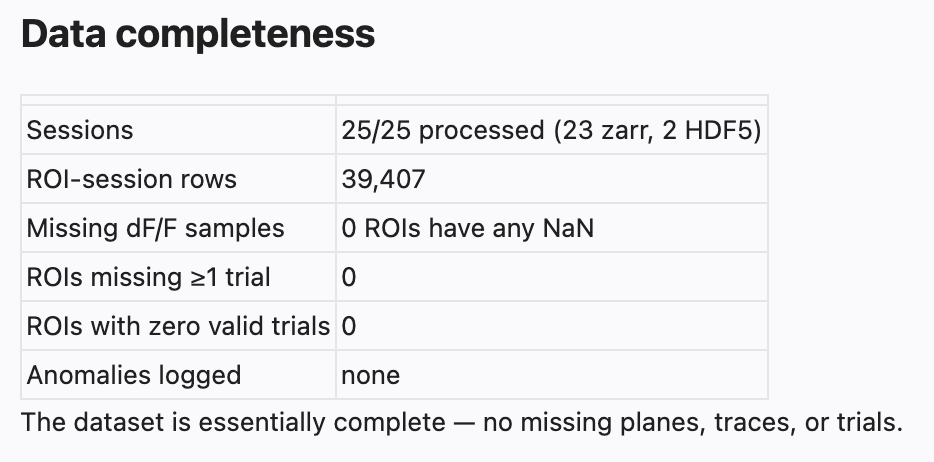

</div>

Clause notes / believes that:

- Every ROI appears in exactly one session so "there is no cross-session ROI overlap to reconcile, so "cells in multiple sessions" (a concern raised in your Step 4 verification notes) doesn't arise."

- ```is_soma == False``` for 1,038 ROIs, all concentrated in a single session, so we should filter on this parameter. 

- A few trials have NaN direction

Claude checked for a number of potential anomolous conditions and wrote errors (if any) to a json file in scratch/v1dd_step2/shards/meta:
```python 
(SHARD_DIR / 'meta' / f'{session_name}.json').write_text(json.dumps(rec, default=str))
```


#### [Verification]

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

Was data saved to a good format? Do the values look reasonable? Does metadata look correct?

Looks like final output was assembled to roi_tuning.parquet

In [8]:
OUT_DIR   = Path('/scratch/v1dd_step2')
df_tuning = pd.read_parquet(OUT_DIR / 'roi_tuning.parquet')
print(df_tuning.shape)
print(df_tuning.columns)

tuning_cols = ['ori_mean_0', 'ori_sd_0', 'ori_n_0', 'ori_mean_30',
       'ori_sd_30', 'ori_n_30', 'ori_mean_60', 'ori_sd_60', 'ori_n_60',
       'ori_mean_90', 'ori_sd_90', 'ori_n_90', 'ori_mean_120', 'ori_sd_120',
       'ori_n_120', 'ori_mean_150', 'ori_sd_150', 'ori_n_150', 'dir_mean_0',
       'dir_sd_0', 'dir_n_0', 'dir_mean_30', 'dir_sd_30', 'dir_n_30',
       'dir_mean_60', 'dir_sd_60', 'dir_n_60', 'dir_mean_90', 'dir_sd_90',
       'dir_n_90', 'dir_mean_120', 'dir_sd_120', 'dir_n_120', 'dir_mean_150',
       'dir_sd_150', 'dir_n_150', 'dir_mean_180', 'dir_sd_180', 'dir_n_180',
       'dir_mean_210', 'dir_sd_210', 'dir_n_210', 'dir_mean_240', 'dir_sd_240',
       'dir_n_240', 'dir_mean_270', 'dir_sd_270', 'dir_n_270', 'dir_mean_300',
       'dir_sd_300', 'dir_n_300', 'dir_mean_330', 'dir_sd_330', 'dir_n_330']

tuning_means_cols = [col for col in tuning_cols if "mean" in col]

# dir_n values are small integers
print(np.max(df_tuning[tuning_means_cols], axis=None))   
print(np.min(df_tuning[tuning_means_cols], axis=None))

df_tuning.head()

(39407, 66)
Index(['session_name', 'column', 'volume', 'plane', 'roi', 'roi_idx',
       'plane_name', 'is_soma', 'n_frames', 'frac_nan_dff', 'n_trials_total',
       'n_trials_valid', 'ori_mean_0', 'ori_sd_0', 'ori_n_0', 'ori_mean_30',
       'ori_sd_30', 'ori_n_30', 'ori_mean_60', 'ori_sd_60', 'ori_n_60',
       'ori_mean_90', 'ori_sd_90', 'ori_n_90', 'ori_mean_120', 'ori_sd_120',
       'ori_n_120', 'ori_mean_150', 'ori_sd_150', 'ori_n_150', 'dir_mean_0',
       'dir_sd_0', 'dir_n_0', 'dir_mean_30', 'dir_sd_30', 'dir_n_30',
       'dir_mean_60', 'dir_sd_60', 'dir_n_60', 'dir_mean_90', 'dir_sd_90',
       'dir_n_90', 'dir_mean_120', 'dir_sd_120', 'dir_n_120', 'dir_mean_150',
       'dir_sd_150', 'dir_n_150', 'dir_mean_180', 'dir_sd_180', 'dir_n_180',
       'dir_mean_210', 'dir_sd_210', 'dir_n_210', 'dir_mean_240', 'dir_sd_240',
       'dir_n_240', 'dir_mean_270', 'dir_sd_270', 'dir_n_270', 'dir_mean_300',
       'dir_sd_300', 'dir_n_300', 'dir_mean_330', 'dir_sd_330', 'dir_n_330'],


,session_name,column,volume,plane,roi,roi_idx,plane_name,is_soma,n_frames,frac_nan_dff,...,dir_n_240,dir_mean_270,dir_sd_270,dir_n_270,dir_mean_300,dir_sd_300,dir_n_300,dir_mean_330,dir_sd_330,dir_n_330
0,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,0,0,plane-0,True,22029,0.0,...,13,0.105825,0.122524,16,0.052025,0.148083,16,0.146717,0.180939,16
1,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,1,1,plane-0,True,22029,0.0,...,13,0.126093,0.125789,16,0.095545,0.169057,16,0.134756,0.202665,16
2,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,2,2,plane-0,True,22029,0.0,...,13,0.201917,0.244626,16,0.097549,0.293270,16,0.113010,0.269598,16
3,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,4,3,plane-0,True,22029,0.0,...,13,0.097958,0.135743,16,0.101672,0.076455,16,0.022601,0.293034,16
4,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,5,4,plane-0,True,22029,0.0,...,13,0.081953,0.195220,16,0.107958,0.142503,16,0.013594,0.325683,16


,session_name,column,volume,plane,roi,roi_idx,plane_name,is_soma,n_frames,frac_nan_dff,...,dir_n_240,dir_mean_270,dir_sd_270,dir_n_270,dir_mean_300,dir_sd_300,dir_n_300,dir_mean_330,dir_sd_330,dir_n_330
124,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,3,16,16,plane-3,True,22030,0.0,...,13,5.675139,3.38983,16,-0.097706,2.339258,16,-1.111728,1.403643,16


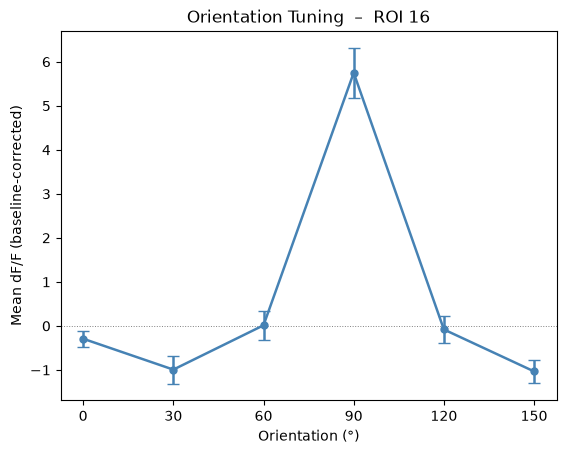

In [9]:
# Let's check our test cell from step 1
test_session_name = '409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00'
test_plane = 'plane-3'
test_roi = 16

filtered_df = df_tuning.loc[((df_tuning['session_name'] == test_session_name) &  
             (df_tuning['plane_name'] == test_plane) & 
             (df_tuning['roi'] == test_roi))]

fig, ax = plt.subplots(1,1)
ori_cols = ['ori_mean_0', 'ori_sd_0', 'ori_n_0', 'ori_mean_30',
       'ori_sd_30', 'ori_n_30', 'ori_mean_60', 'ori_sd_60', 'ori_n_60',
       'ori_mean_90', 'ori_sd_90', 'ori_n_90', 'ori_mean_120', 'ori_sd_120',
       'ori_n_120', 'ori_mean_150', 'ori_sd_150', 'ori_n_150']

def reshape_tuning (df):
    wide = df[ori_cols].copy()
    wide.index.name = "curve_id"

    tuning = (
        pd.wide_to_long(
            wide.reset_index(),
            stubnames=["ori_mean", "ori_sd", "ori_n"],
            i="curve_id",
            j="orientation",
            sep="_",
            suffix=r"\d+",
        )
        .reset_index()
        .rename(
            columns={
                "ori_mean": "mean_response",
                "ori_sd": "sd",
                "ori_n": "n",
            }
        )
        .sort_values(["curve_id", "orientation"])
    )

    # Calculate SEM, avoiding invalid division when n is zero.
    tuning["sem"] = np.where(
        tuning["n"] > 0,
        tuning["sd"] / np.sqrt(tuning["n"]),
        np.nan,
    )
    return tuning

tuning = reshape_tuning (filtered_df)

oris  = tuning['orientation'].values
means = tuning['mean_response'].values
sems  = tuning['sem'].values

ax.errorbar(oris, means, yerr=sems, fmt='o-', capsize=4,
             color='steelblue', ecolor='steelblue', lw=1.8, ms=5)

ax.axhline(0, color='gray', ls=':', lw=0.7)
ax.set_xticks(oris)
ax.set_xlabel('Orientation (°)')
ax.set_ylabel('Mean dF/F (baseline-corrected)')
ax.set_title(f"Orientation Tuning  –  ROI {test_roi}")
           
filtered_df

Text(0.5, 0.98, 'Randomly selected subset of tuning curves')

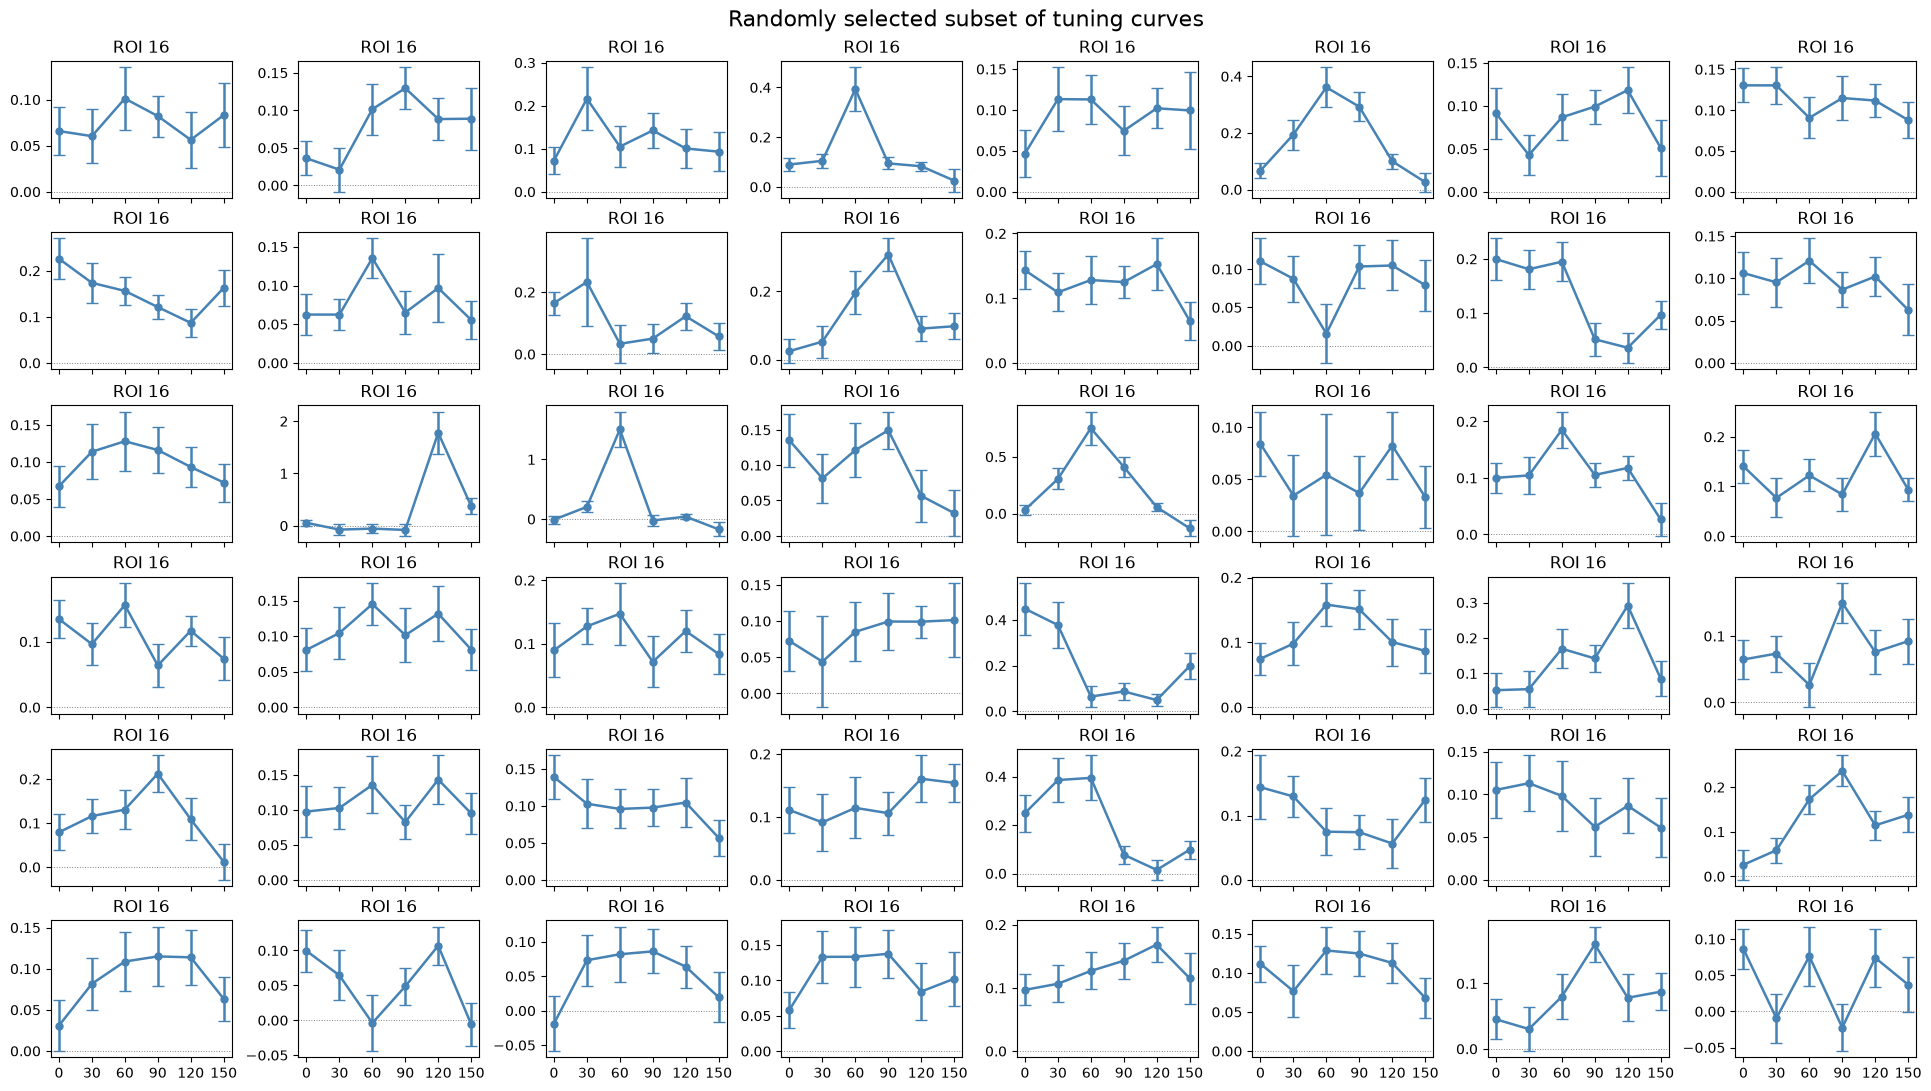

In [10]:
# Randomly plot tuning curves

nrows = 6
ncols = 8
seed = 42
figsize_per_panel = (2.4, 1.8)

n_panels = nrows * ncols
n_curves = df_tuning.shape[0]

rng = np.random.default_rng(seed)
sampled_indices = rng.choice(n_curves, size=n_panels, replace=False)

figure_size = (
        ncols * figsize_per_panel[0],
        nrows * figsize_per_panel[1],
)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=figure_size,
    sharex=True,
    sharey=False,
    constrained_layout=True
)

for i, ax in enumerate(axes.flatten()):
    df_row = df_tuning.iloc[[i]]
    tuning = reshape_tuning (df_row)

    oris  = tuning['orientation'].values
    means = tuning['mean_response'].values
    sems  = tuning['sem'].values

    ax.errorbar(oris, means, yerr=sems, fmt='o-', capsize=4,
                color='steelblue', ecolor='steelblue', lw=1.8, ms=5)

    ax.axhline(0, color='gray', ls=':', lw=0.7)
    ax.set_xticks(oris)
    #ax.set_xlabel('Orientation (°)')
    #ax.set_ylabel('Mean dF/F (baseline-corrected)')
    ax.set_title(f"ROI {test_roi}")

plt.suptitle("Randomly selected subset of tuning curves", fontsize = 16)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

Do these tunings look okay?

How do we want to handle noisy basically non-responsive neurons?

What constitutes "responsive"?

In a real research situation, more formal verification with previously computed data would be appropriate.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### [Prompt]

Next, 
- Compute tuning width from tuning curves (stored in /scratch/v1dd_step2/roi_tuning.parquet)
- Compute orientation selectivity index (OSI)
- Consult https://github.com/AllenInstitute/v1dd_physiology
- Create a scatterplot comparing tuning width and OSI across samples

Output format:
- Please write a code block in the section of this Jupyter notebook after "Step 3: Compute tuning metrics"
- Start accumulating tuning curve and tuning metrics into a dataframe organized by "roi" identifier.

#### Step 3: Compute tuning metrics

<span style="color:red"> Warning: Please do not run the subsequent code to fit the tuning curves (this run took 119 minutes). This code has already been run for you. </span>

```python
# GENERATED CODE

# === Step 3: Compute Tuning Metrics ===
# Formulas follow the Allen Institute NeuroAnalysisTools / v1dd_physiology conventions
# (github.com/zhuangjun1981/NeuroAnalysisTools, SingleCellAnalysis.py):
#
# OSI  = (R_pref − R_orth) / (R_pref + R_orth)
#   R_pref: mean response at the preferred orientation (argmax of orientation curve)
#   R_orth: mean response at the orthogonal orientation (pref + 90° mod 180°)
#
# gOSI (global OSI / 1 − circular variance, Ringach et al. 2002):
#   gOSI = | Σ R_i · exp(2i·θ_i) | / Σ max(R_i, 0)
#   More robust than OSI when some responses are negative (noise floor).
#   Preferred orientation is also recovered from this vector's phase angle.
#
# Tuning width (FWHH) — two-peak von Mises fit to the 12-direction curve:
#   R(θ) = r0 + a1·exp(k·(cos(θ−θ_pref)−1)) + a2·exp(k·(cos(θ−θ_pref−π)−1))
#   FWHH = 2·arccos(ln(0.5)/k + 1)·(180/π)  degrees
#   The fit uses the rectified (negative-clipped) direction curve for stability.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

OUT_DIR = Path('/scratch/v1dd_step2')

# ── 1. Load data ──────────────────────────────────────────────────────────────
tuning_df = pd.read_parquet(OUT_DIR / 'roi_tuning.parquet')

ORIENTATIONS  = np.array([0, 30, 60, 90, 120, 150], dtype=float)
DIRECTIONS    = np.array([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330], dtype=float)
ORI_MEAN_COLS = [f'ori_mean_{int(o)}' for o in ORIENTATIONS]
DIR_MEAN_COLS = [f'dir_mean_{int(d)}' for d in DIRECTIONS]
KEY_COLS      = ['session_name', 'column', 'volume', 'plane', 'roi', 'roi_idx', 'plane_name']

R_ori = tuning_df[ORI_MEAN_COLS].to_numpy(dtype=float)   # (n_rois, 6)
R_dir = tuning_df[DIR_MEAN_COLS].to_numpy(dtype=float)   # (n_rois, 12)

# ── 2. OSI — Allen convention: (R_pref − R_orth) / (R_pref + R_orth) ─────────
# Preferred orientation: argmax of the mean orientation responses.
# Orthogonal: (pref + 90°) mod 180°, which always lands exactly on one of the
# 6 sampled orientations since they are spaced 30° apart.
pref_idx     = np.argmax(R_ori, axis=1)                   # column index into ORIENTATIONS
pref_ori     = ORIENTATIONS[pref_idx]                     # degrees (discrete argmax)
orth_ori     = (pref_ori + 90) % 180
orth_idx     = np.searchsorted(ORIENTATIONS, orth_ori)    # exact match guaranteed

R_pref    = R_ori[np.arange(len(R_ori)), pref_idx]
R_orth    = R_ori[np.arange(len(R_ori)), orth_idx]
denom_osi = R_pref + R_orth
# OSI can exceed [0,1] when the orthogonal response is negative (noise floor).
# Allen also provides an OSI_rec variant on rectified curves for stability.
OSI = np.where(np.abs(denom_osi) > 1e-9, (R_pref - R_orth) / denom_osi, np.nan)

# ── 3. gOSI — global OSI via vector sum ───────────────────────────────────────
theta_rad = np.deg2rad(2 * ORIENTATIONS)   # doubled angles: maps 180° period → 360°
R_pos     = np.clip(R_ori, 0, None)        # clip negatives before summing
vec_sum   = (R_pos * np.exp(1j * theta_rad)).sum(axis=1)
denom_g   = R_pos.sum(axis=1)
gOSI      = np.where(denom_g > 0, np.abs(vec_sum) / denom_g, np.nan)

# Preferred orientation from the continuous vector (not binned to 30° steps)
pref_ori_vec = (np.rad2deg(np.angle(vec_sum)) / 2) % 180

# ── 4. Tuning width — two-peak von Mises fit to direction data ────────────────
dir_rad = np.deg2rad(DIRECTIONS)

def two_peak_von_mises(theta, r0, a1, a2, k, peak_dir):
    """Two von Mises peaks separated by 180° (Allen NeuroAnalysisTools convention)."""
    peak_arc = np.deg2rad(peak_dir)
    return (r0
            + a1 * np.exp(k * (np.cos(theta - peak_arc)         - 1))
            + a2 * np.exp(k * (np.cos(theta - peak_arc - np.pi) - 1)))

def fit_tuning_width(dir_responses, pref_dir_deg):
    """
    Fit two-peak von Mises to the rectified direction curve.
    Returns FWHH in degrees, or NaN on failure.
    FWHH = 2·arccos(ln(0.5)/k + 1)·(180/π)
    """
    R_rect = np.clip(dir_responses, 0, None)
    A_init = R_rect.max() - R_rect.min()
    p0     = [R_rect.min(), max(A_init, 1e-6), max(A_init * 0.1, 1e-6), 1.5, pref_dir_deg]
    bounds = ([-np.inf, 0,       0,       0.01, 0  ],
              [ np.inf, np.inf,  np.inf,  50,   360 ])
    try:
        popt, _ = curve_fit(two_peak_von_mises, dir_rad, R_rect,
                             p0=p0, bounds=bounds, maxfev=3000)
        k   = popt[3]
        arg = np.log(0.5) / k + 1
        if not (-1 <= arg <= 1):   # arccos domain — k too small → flat tuning
            return np.nan
        return 2 * np.arccos(arg) * 180 / np.pi
    except Exception:
        return np.nan

# Initialise each fit at the argmax direction
pref_dir_discrete = DIRECTIONS[np.argmax(R_dir, axis=1)]

print(f"Fitting tuning widths for {len(R_dir):,} ROIs ...")
tuning_width = np.array([
    fit_tuning_width(R_dir[i], pref_dir_discrete[i])
    for i in range(len(R_dir))
])
print("Done.")

# ── 5. Assemble per-ROI metrics dataframe ─────────────────────────────────────
# The composite key (session_name, column, volume, plane, roi) matches
# coregistration_1196.feather for the Step 4 merge — 'roi' alone is NOT unique.
metrics_df = tuning_df[KEY_COLS].copy()
metrics_df['pref_ori']     = pref_ori        # discrete argmax orientation (deg)
metrics_df['pref_ori_vec'] = pref_ori_vec    # vector-sum preferred orientation (deg)
metrics_df['OSI']          = OSI             # (R_pref - R_orth) / (R_pref + R_orth)
metrics_df['gOSI']         = gOSI            # vector-sum magnitude
metrics_df['tuning_width'] = tuning_width    # FWHH in degrees (von Mises fit)

# Attach orientation mean columns for downstream tuning curve plots (Step 4)
metrics_df = pd.concat([metrics_df, tuning_df[ORI_MEAN_COLS]], axis=1)

n = len(metrics_df)
print(f"\nROIs total          : {n:,}")
for col in ['OSI', 'gOSI', 'tuning_width']:
    ok = np.isfinite(metrics_df[col]).sum()
    print(f"  {col:16s}: {ok:,} valid ({100*ok/n:.1f}%)  "
          f"median={metrics_df[col].median():.3f}  mean={metrics_df[col].mean():.3f}")

metrics_df.to_parquet(OUT_DIR / 'roi_metrics.parquet', index=False)
print(f"\nSaved -> {OUT_DIR / 'roi_metrics.parquet'}")

# ── 6. Scatter plot: tuning width vs OSI ──────────────────────────────────────
valid = metrics_df['OSI'].notna() & metrics_df['tuning_width'].notna()
m = metrics_df[valid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: scatter coloured by preferred orientation
ax = axes[0]
sc = ax.scatter(m['tuning_width'], m['OSI'],
                c=m['pref_ori_vec'], cmap='hsv',
                s=3, alpha=0.25, linewidths=0, rasterized=True)
ax.set_xlabel('Tuning width FWHH (deg)')
ax.set_ylabel('OSI')
ax.set_title('Tuning width vs OSI\n(colour = preferred orientation)')
plt.colorbar(sc, ax=ax, label='Preferred orientation (deg)')

# Right: 2-D density histogram
ax2 = axes[1]
h = ax2.hist2d(m['tuning_width'], m['OSI'],
               bins=[np.linspace(0, 180, 60), np.linspace(-1, 2, 50)],
               cmap='Blues', density=True)
plt.colorbar(h[3], ax=ax2, label='Density')
ax2.set_xlabel('Tuning width FWHH (deg)')
ax2.set_ylabel('OSI')
ax2.set_title('2-D density: tuning width vs OSI')

plt.suptitle(f'Orientation tuning metrics  -  {valid.sum():,} ROIs', fontsize=11)
plt.tight_layout()
plt.show()
```

The output:
<img src="img/Tuning_OSI_output.png" width="900">

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DDEDE4;">

#### [Our Interaction]

It spends a lot of time (and tokens) analyzing the v1dd_physiology Github. Then it created this summary of formulas:

<img src="img/summary_of_formulas2.png" width="750">

It notes that:

1. OSI can exceed 1 (if responses are negative) ; gOSI is bounded [0,1] and is more stable.

2. Tuning width hits the k=50 upper bound for sharp tuners. The 30° sampling interval limits resolution — tuning widths below ~30° are extrapolations of the von Mises shape, not directly measured.

Output is written to: roi_metrics.parquet keyed by (session_name, column, volume, plane, roi).


#### [Verification]

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">
Some things to think about:

-Are the metrics correctly defined? 

-Are they correctly implemented?

-Do the two metrics roughly agree with each other?

-Does the plot make sense?

In [11]:
OUT_DIR = Path('/scratch/v1dd_step2')   # Shouldn't this be saved to v1dd_step3?
metrics_df =pd.read_parquet(OUT_DIR / 'roi_metrics.parquet')
print(np.min(metrics_df['tuning_width']), np.max(metrics_df['tuning_width']))
print(np.min(metrics_df['OSI']), np.max(metrics_df['OSI']))     # This is intended to range between 0 and 1
print(np.min(metrics_df['gOSI']), np.max(metrics_df['gOSI']))     # This should range between 0 and 1
metrics_df

# Are these tuning width values reasonable? OSI's?

19.102858156288505 347.9110468388961
-783.9340608829435 1494.6163260275962
0.001641011855535951 1.0000000000000002


,session_name,column,volume,plane,roi,roi_idx,plane_name,pref_ori,pref_ori_vec,OSI,gOSI,tuning_width,ori_mean_0,ori_mean_30,ori_mean_60,ori_mean_90,ori_mean_120,ori_mean_150
0,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,0,0,plane-0,60.0,70.340816,0.097751,0.066989,NaN,0.065912,0.060365,0.101206,0.082177,0.056372,0.083182
1,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,1,1,plane-0,90.0,99.761318,0.564299,0.304446,NaN,0.036072,0.020966,0.101568,0.129508,0.088379,0.088818
2,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,2,2,plane-0,30.0,49.605781,0.365127,0.153137,19.102858,0.072569,0.216437,0.104925,0.142514,0.100657,0.093228
3,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,4,3,plane-0,60.0,58.867205,0.879025,0.482293,32.126415,0.090063,0.104926,0.393460,0.094587,0.082980,0.025332
4,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,5,4,plane-0,30.0,71.844791,0.052006,0.065664,NaN,0.046663,0.113269,0.112910,0.074586,0.102070,0.099461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39402,409828_2018-12-14_14-47-35_filtered_2026-04-09...,1,5,5,182,116,plane-5,150.0,136.515932,1.377273,0.599488,19.102906,-0.008836,-0.001110,-0.003598,0.010204,0.000171,0.022674
39403,409828_2018-12-14_14-47-35_filtered_2026-04-09...,1,5,5,207,117,plane-5,60.0,15.313365,0.119358,0.356146,19.102892,0.016662,0.008529,0.020187,-0.015035,-0.000219,0.015882
39404,409828_2018-12-14_14-47-35_filtered_2026-04-09...,1,5,5,217,118,plane-5,60.0,60.758573,-17.728397,0.419006,36.957554,-0.011377,0.007791,0.011792,-0.007681,0.008146,-0.013202
39405,409828_2018-12-14_14-47-35_filtered_2026-04-09...,1,5,5,263,119,plane-5,150.0,133.974365,3.477471,0.566016,19.102860,-0.000678,-0.000525,-0.004971,0.004771,-0.013453,0.008985


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

The plots and the values don't seem surprising. Should I have used a better language model since this involved analyzing an existing code base? Should I have built these metrics out for a single test case before triggering a batch run?

OSI should be between 0 and 1, but if responses are negative (suppressive), it can exceed 1 as the LLM pointed out.

Let's check the relevant lines of code for computating for OSI.

We can also empirically see what it is doing.

In [12]:
# Examine first chunk of step 3 code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

OUT_DIR = Path('/scratch/v1dd_step2')

# ── 1. Load data ──────────────────────────────────────────────────────────────
tuning_df = pd.read_parquet(OUT_DIR / 'roi_tuning.parquet')

ORIENTATIONS  = np.array([0, 30, 60, 90, 120, 150], dtype=float)
DIRECTIONS    = np.array([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330], dtype=float)
ORI_MEAN_COLS = [f'ori_mean_{int(o)}' for o in ORIENTATIONS]
DIR_MEAN_COLS = [f'dir_mean_{int(d)}' for d in DIRECTIONS]
KEY_COLS      = ['session_name', 'column', 'volume', 'plane', 'roi', 'roi_idx', 'plane_name']

R_ori = tuning_df[ORI_MEAN_COLS].to_numpy(dtype=float)   # (n_rois, 6)
R_dir = tuning_df[DIR_MEAN_COLS].to_numpy(dtype=float)   # (n_rois, 12)

# ── 2. OSI — Allen convention: (R_pref − R_orth) / (R_pref + R_orth) ─────────
# Preferred orientation: argmax of the mean orientation responses.
# Orthogonal: (pref + 90°) mod 180°, which always lands exactly on one of the
# 6 sampled orientations since they are spaced 30° apart.
pref_idx     = np.argmax(R_ori, axis=1)                   # column index into ORIENTATIONS
pref_ori     = ORIENTATIONS[pref_idx]                     # degrees (discrete argmax)
orth_ori     = (pref_ori + 90) % 180
orth_idx     = np.searchsorted(ORIENTATIONS, orth_ori)    # exact match guaranteed

R_pref    = R_ori[np.arange(len(R_ori)), pref_idx]
R_orth    = R_ori[np.arange(len(R_ori)), orth_idx]
denom_osi = R_pref + R_orth
# OSI can exceed [0,1] when the orthogonal response is negative (noise floor).
# Allen also provides an OSI_rec variant on rectified curves for stability.
OSI = np.where(np.abs(denom_osi) > 1e-9, (R_pref - R_orth) / denom_osi, np.nan)

# Check that these look right for first 10 rows
df_ori = pd.DataFrame(R_ori, columns=ORI_MEAN_COLS)
df_ori['pref_ori'] = pref_ori
df_ori['R_pref'] = R_pref
df_ori['R_orth'] = R_orth
df_ori[1:10]

,ori_mean_0,ori_mean_30,ori_mean_60,ori_mean_90,ori_mean_120,ori_mean_150,pref_ori,R_pref,R_orth
1,0.036072,0.020966,0.101568,0.129508,0.088379,0.088818,90.0,0.129508,0.036072
2,0.072569,0.216437,0.104925,0.142514,0.100657,0.093228,30.0,0.216437,0.100657
3,0.090063,0.104926,0.393460,0.094587,0.082980,0.025332,60.0,0.393460,0.025332
4,0.046663,0.113269,0.112910,0.074586,0.102070,0.099461,30.0,0.113269,0.102070
5,0.066772,0.194365,0.361376,0.292642,0.099927,0.026003,60.0,0.361376,0.026003
6,0.091407,0.042854,0.086717,0.099187,0.118388,0.051169,120.0,0.118388,0.042854
7,0.130425,0.130380,0.090590,0.114900,0.111802,0.087834,0.0,0.130425,0.114900
8,0.226104,0.173879,0.156349,0.121256,0.087014,0.162722,0.0,0.226104,0.121256
9,0.062488,0.062441,0.135363,0.065131,0.096766,0.055595,60.0,0.135363,0.055595


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">
The selection of the preferred orientation and the responses at preferred and orthogonal stimuli seem right for these cases.

In [13]:
# Let's look at the lines that are the extrema weird values

min_ind = np.argmin(metrics_df['OSI'])
max_ind = np.argmax(metrics_df['OSI'])
print(min_ind)
print(max_ind)
metrics_df.iloc[[min_ind,max_ind]]

34197
35600


,session_name,column,volume,plane,roi,roi_idx,plane_name,pref_ori,pref_ori_vec,OSI,gOSI,tuning_width,ori_mean_0,ori_mean_30,ori_mean_60,ori_mean_90,ori_mean_120,ori_mean_150
34197,409828_2018-12-13_15-10-05_filtered_2026-04-09...,1,3,1,289,271,plane-1,0.0,176.627237,-783.934061,0.534565,304.140930,0.030839,0.009907,-0.005524,-0.030918,0.013734,0.000132
35600,409828_2018-12-13_15-10-05_filtered_2026-04-09...,1,3,4,258,243,plane-4,120.0,123.518498,1494.616326,0.712100,19.102881,-0.007845,-0.020455,0.003790,-0.007899,0.020482,0.006933


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

We can check that (0.020482-(-0.020455))/(0.020482+(-0.020455)) is a large positive number and that (0.030839-(-0.030918))/(0.030839+(-0.030918)) is a large negative number close to their reported OSI's (likely some floating point imprecision). Yet these units are essentially non-responsive. Let's try the more computationally stable and bounded gOSI metric and filter to positively responsive units.

(39407, 18)
(1685, 18)
0    19.102858
Name: tuning_width, dtype: float64


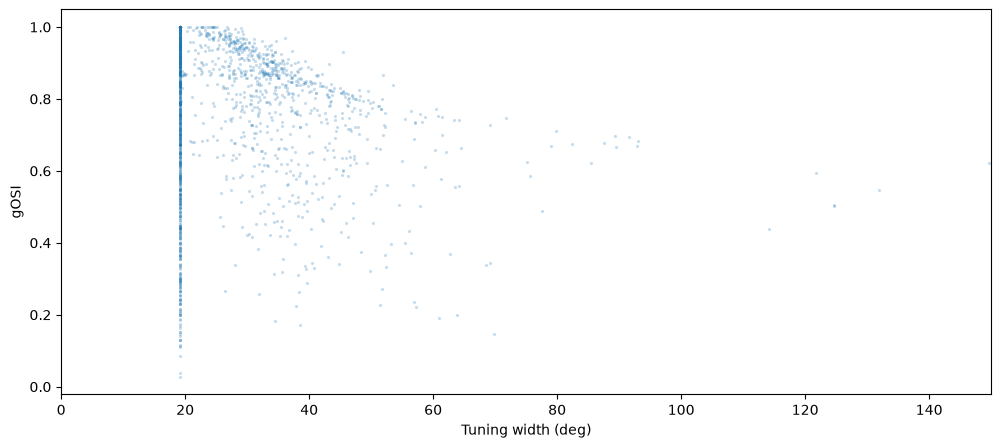

In [14]:
# Filter on positive responsive units (R_pref > 0.1)

metrics_filt = metrics_df[np.max(metrics_df[ORI_MEAN_COLS], axis = 1) > 0.2].copy()
print(metrics_df.shape)
print(metrics_filt.shape) 

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.scatter(metrics_filt['tuning_width'], metrics_filt['gOSI'],
                s=5, alpha=0.25, linewidths=0, rasterized=True)
ax.set_xlabel('Tuning width (deg)')
ax.set_ylabel('gOSI')
ax.set_xlim(0,150)

# What are tuning width values streaked on the left?
print(metrics_filt['tuning_width'].mode())


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

This looks more reasonable - as the tuning width increases, the selectivity index drops. What about that minimum and modal tuning width of 19.1? As the LLM noted, the Allen SDK caps κ at 50 in the von Mises fitter, corresponding to FWHH of 19.1 (the FWHH formula is 2 · arccos(ln(0.5)/κ + 1) · (180/π)). Any cell whose response drops below 50% of peak within 30° gets assigned the same minimum FWHH. 


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

Let's create some toy data and see if fitting works correctly.

29.999999920625804
0.976895093920204
24.680814553513454


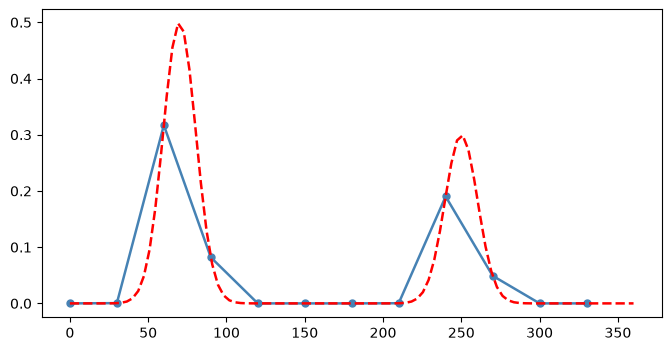

In [15]:
# Test on synthetic data

DIRECTIONS    = np.array([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330], dtype=float)
R_offset = 0 
a1 = 0.5
a2 = 0.3
k = 30
peak_arc = 70

R_dir = R_offset + a1 * np.exp(k * (np.cos(np.deg2rad(DIRECTIONS) - np.deg2rad(peak_arc)) - 1)) \
        + a2 * np.exp(k * (np.cos(np.deg2rad(DIRECTIONS) - np.deg2rad(peak_arc + 180)) - 1))
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(DIRECTIONS, R_dir, 'o-', color='steelblue', lw=1.8, ms=5)

dir_rad = np.deg2rad(DIRECTIONS)
def two_peak_von_mises(theta, r0, a1, a2, k, peak_dir):
    """Two von Mises peaks separated by 180° (Allen NeuroAnalysisTools convention)."""
    peak_arc = np.deg2rad(peak_dir)
    return (r0
            + a1 * np.exp(k * (np.cos(theta - peak_arc)         - 1))
            + a2 * np.exp(k * (np.cos(theta - peak_arc - np.pi) - 1)))

def fit_tuning_width(dir_responses, pref_dir_deg):
    """
    Fit two-peak von Mises to the rectified direction curve.
    Returns FWHH in degrees, or NaN on failure.
    FWHH = 2·arccos(ln(0.5)/k + 1)·(180/π)
    """
    R_rect = np.clip(dir_responses, 0, None)
    A_init = R_rect.max() - R_rect.min()
    p0     = [R_rect.min(), max(A_init, 1e-6), max(A_init * 0.1, 1e-6), 1.5, pref_dir_deg]
    bounds = ([-np.inf, 0,       0,       0.01, 0  ],
              [ np.inf, np.inf,  np.inf,  50,   360 ])
    try:
        popt, _ = curve_fit(two_peak_von_mises, dir_rad, R_rect,
                             p0=p0, bounds=bounds, maxfev=3000)
        k   = popt[3]
        arg = np.log(0.5) / k + 1
        print(k)
        print(arg)
        if not (-1 <= arg <= 1):   # arccos domain — k too small → flat tuning
            return np.nan
        return 2 * np.arccos(arg) * 180 / np.pi, popt
    except Exception:
        return np.nan, np.nan
# Initialise each fit at the argmax direction
pref_dir_discrete = DIRECTIONS[np.argmax(R_dir)]

tuning_width, popt = fit_tuning_width(R_dir, pref_dir_discrete)
print(tuning_width)

x_fit = np.linspace(0, 360, 100)
y_fit = two_peak_von_mises(np.deg2rad(x_fit), *popt)
ax.plot(x_fit, y_fit, '--', color='red', lw=1.8)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

#### Task 1:

Please further verify this code. 

-For instance, sort the sample of cell from high to low tuning width and visualize if the tuning curves make sense

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### [Prompt]
Next,
- Merge this with the cell type and connectivity information
- Plot tuning curves for each cell type - include individual (thin traces) and average (thick trace)
- Compute mean tuning widths / OSI for each cell type

Output format:
- Please write a code block in the section of the Code_verification_V1DD_Functional_Data Jupyter notebook after "Step 4: Coregisteration with EM data and examination of tuning as a function of cell type"

#### Step 4: Coregisteration with EM data and examination of tuning as a function of cell type

/opt/conda/lib/python3.12/site-packages/pandas/io/feather_format.py:178: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  pa_table = feather.read_table(


After merge: 498 ROI-session rows with EM cell type
cell_type
L3-IT    208
L5-ET    148
L4-IT    120
L5-IT     19
L5-NP      3
Name: count, dtype: int64

After responsiveness filter (R_pref > 0.2): 46 cells
cell_type
L5-ET    28
L3-IT    10
L4-IT     6
L5-IT     2
Name: count, dtype: int64


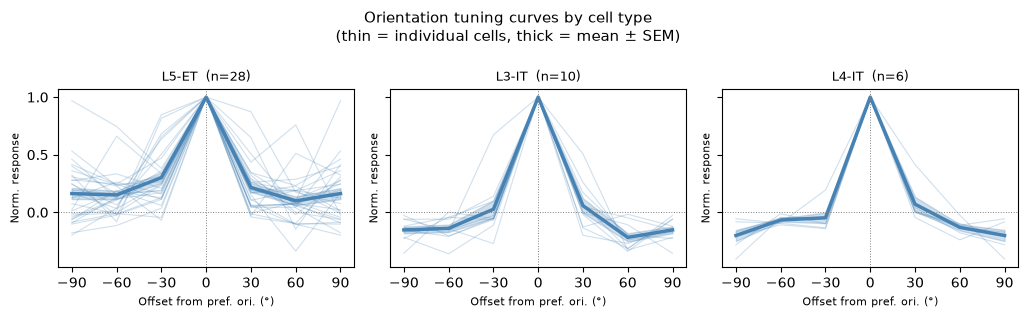

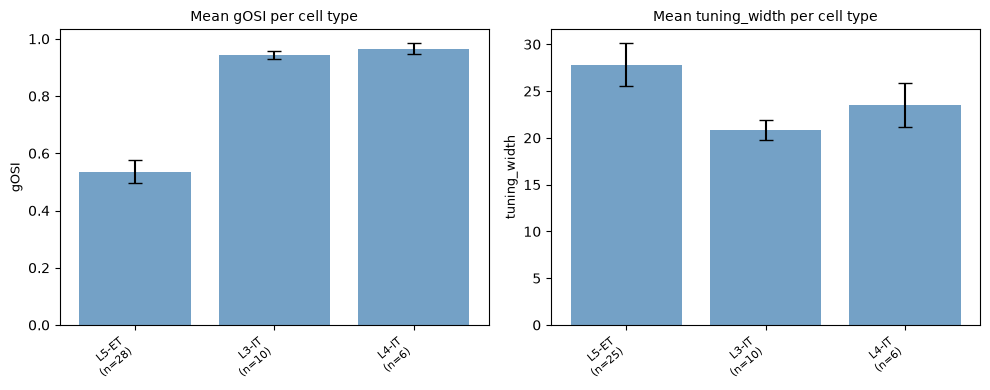


Numerical summary (responsive cells only):
            gOSI              tuning_width             
            mean    sem count         mean    sem count
cell_type                                              
L3-IT      0.945  0.014    10       20.831  1.050    10
L4-IT      0.966  0.018     6       23.500  2.377     6
L5-ET      0.535  0.040    28       27.833  2.262    25
L5-IT      0.796  0.144     2       19.103  0.000     2


In [16]:
# GENERATED CODE

# === Step 4: Coregistration with EM data and examination of tuning as a function of cell type ===

# ── 4.1 Load data ──────────────────────────────────────────────────────────────
OUT_DIR   = Path('/scratch/v1dd_step2')
DATA_PATH = '/data/v1dd_1196/'

metrics_df = pd.read_parquet(OUT_DIR / 'roi_metrics.parquet')
df_coreg   = pd.read_feather(os.path.join(DATA_PATH, 'coregistration_1196.feather'))
df_ct      = pd.read_feather(os.path.join(DATA_PATH, 'soma_and_cell_type_1196.feather'))

# ── 4.2 Merge: functional metrics → EM identity → cell type ────────────────────
# column and volume are strings in metrics_df but integers in df_coreg
metrics_df['column'] = metrics_df['column'].astype(int)
metrics_df['volume'] = metrics_df['volume'].astype(int)

coreg_unique = df_coreg[['pt_root_id', 'column', 'volume', 'plane', 'roi']].drop_duplicates()
merged = metrics_df.merge(coreg_unique, on=['column', 'volume', 'plane', 'roi'], how='inner')

ct_lookup = (df_ct[['pt_root_id', 'cell_type']]
             .dropna(subset=['cell_type'])
             .drop_duplicates(subset='pt_root_id'))
merged = merged.merge(ct_lookup, on='pt_root_id', how='inner')

print(f"After merge: {merged.shape[0]} ROI-session rows with EM cell type")
print(merged['cell_type'].value_counts())

# ── 4.3 Filter for visually responsive cells (R_pref > 0.2 dF/F) ───────────────
ORI_MEAN_COLS = ['ori_mean_0', 'ori_mean_30', 'ori_mean_60',
                 'ori_mean_90', 'ori_mean_120', 'ori_mean_150']

merged_filt = merged[merged[ORI_MEAN_COLS].max(axis=1) > 0.2].copy()
print(f"\nAfter responsiveness filter (R_pref > 0.2): {merged_filt.shape[0]} cells")
print(merged_filt['cell_type'].value_counts())

# ── 4.4 Plot tuning curves per cell type ───────────────────────────────────────
# Each cell's tuning curve is peak-normalised and rolled so the preferred
# orientation is centred at 0°. The ±90° point is duplicated to give a
# symmetric x-axis from -90° to +90°.

def align_and_normalize(tc):
    """Peak-normalise and roll a 6-point (0–150°) tuning curve to centre at 0."""
    tc = np.asarray(tc, dtype=float)
    peak_idx = int(np.argmax(tc))
    rolled = np.roll(tc, -peak_idx)           # peak is now at index 0
    if rolled[0] > 0:
        rolled = rolled / rolled[0]
    # Map rolled indices to offset degrees: [0, +30, +60, ±90, -60, -30]
    # Reorder to [-90, -60, -30, 0, +30, +60, +90] (duplicate the ±90 point)
    y = rolled[[3, 4, 5, 0, 1, 2, 3]]
    return y

x_plot = np.array([-90, -60, -30, 0, 30, 60, 90])

cell_types = (merged_filt['cell_type'].value_counts()
              .loc[lambda s: s >= 3].index.tolist())          # only types with ≥3 cells

n_types = len(cell_types)
ncols   = min(4, n_types)
nrows   = int(np.ceil(n_types / ncols))
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 3.5, nrows * 3.2),
                          sharey=True, sharex=True,
                          squeeze=False)
axes_flat = axes.ravel()

for ax_idx, ct in enumerate(cell_types):
    ax     = axes_flat[ax_idx]
    subset = merged_filt[merged_filt['cell_type'] == ct]

    all_curves = []
    for _, row in subset.iterrows():
        tc = row[ORI_MEAN_COLS].values.astype(float)
        y  = align_and_normalize(tc)
        ax.plot(x_plot, y, color='steelblue', alpha=0.25, lw=0.8)
        all_curves.append(y)

    if all_curves:
        mean_tc = np.nanmean(all_curves, axis=0)
        sem_tc  = np.nanstd(all_curves, axis=0) / np.sqrt(len(all_curves))
        ax.plot(x_plot, mean_tc, color='steelblue', lw=2.5)
        ax.fill_between(x_plot, mean_tc - sem_tc, mean_tc + sem_tc,
                        color='steelblue', alpha=0.25)

    ax.axhline(0, color='gray', ls=':', lw=0.7)
    ax.axvline(0, color='gray', ls=':', lw=0.7)
    ax.set_title(f'{ct}  (n={len(subset)})', fontsize=9)
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.set_xlabel('Offset from pref. ori. (°)', fontsize=8)
    ax.set_ylabel('Norm. response', fontsize=8)

for idx in range(n_types, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('Orientation tuning curves by cell type\n'
             '(thin = individual cells, thick = mean ± SEM)',
             fontsize=11)
plt.tight_layout()
plt.show()

# ── 4.5 Mean tuning width and gOSI per cell type ───────────────────────────────
# Use gOSI (global OSI, bounded [0,1]) rather than OSI for robustness.

metrics_summary = ['gOSI', 'tuning_width']
fig, axes = plt.subplots(1, len(metrics_summary), figsize=(5 * len(metrics_summary), 4))

for ax, metric in zip(axes, metrics_summary):
    vals    = [merged_filt.loc[merged_filt['cell_type'] == ct, metric].dropna()
               for ct in cell_types]
    means   = [v.mean() for v in vals]
    sems    = [v.sem()  for v in vals]
    ns      = [len(v)   for v in vals]
    labels  = [f'{ct}\n(n={n})' for ct, n in zip(cell_types, ns)]

    x = np.arange(len(cell_types))
    ax.bar(x, means, yerr=sems, capsize=5,
           color='steelblue', alpha=0.75, error_kw={'lw': 1.5})
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_title(f'Mean {metric} per cell type', fontsize=10)
    ax.axhline(0, color='gray', ls=':', lw=0.7)

plt.tight_layout()
plt.show()

# ── 4.6 Print numerical summary ────────────────────────────────────────────────
summary_rows = []
for metric in ['gOSI', 'tuning_width']:
    g = merged_filt.groupby('cell_type')[metric].agg(['mean', 'sem', 'count']).round(3)
    g.columns = pd.MultiIndex.from_tuples([(metric, c) for c in g.columns])
    summary_rows.append(g)
summary = pd.concat(summary_rows, axis=1)
print("\nNumerical summary (responsive cells only):")
print(summary.to_string())

#### [Verification]

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

#### Task 2

Please verify this code. Some things to consider:

- Did it merge correctly?
    - What column did it merge on? What are unique values in the important columns? Consider that a cell is uniquely identified by the combination of its column, volume (the unique combination of 2 is what makes a session), plane and roi and we should not use roi_idx.
    - However, some EM cells have multiple functional entries either across planes in the same session, or across different sessions. Consult "Attach EM root IDs" section of the Functional Data Cell-Cell Correlations.ipynb notebook from the "SWDB 2026 Connectomics" capsule (duplicated here for convenience).
    - Did it do an inner, left, right, outer join, etc.?
    - What were dimensions before and after merge?
    - What does the resulting table look like?


- Do the tuning curves for each cell type look right?
    - Why are there only 4 cell types - are these the only types that have co-registration information?
    - How is it averaging?
    - Do we want to normalize or use raw response amplitudes?
    - Did it aligned the curves to peak?
    - How did it handle circular wrap-around?

- Do the tuning metrics across cell types agree with the tuning curves across cell types?
- Are there any cell type differences and would they be expected based on the literature?

In [17]:
# If you want to look at the coregistration table
path = '/data/v1dd_1196/'
df_coreg = pd.read_feather(os.path.join(path, 'coregistration_1196.feather'))
df_coreg

/opt/conda/lib/python3.12/site-packages/pandas/io/feather_format.py:178: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  pa_table = feather.read_table(


,pt_root_id,column,volume,plane,roi
0,864691132830842994,1,3,0,143
1,864691132741466457,1,3,2,40
2,864691132770893729,1,3,3,98
3,864691132770893729,1,3,3,98
4,864691132999240117,1,3,0,100
...,...,...,...,...,...
566,864691132744008540,1,3,2,236
567,864691132810202401,1,3,2,383
568,864691132925592361,1,3,2,393
569,864691132884727983,1,3,0,89


In [18]:
# Cell types table
df_ct = pd.read_feather(os.path.join(path, 'soma_and_cell_type_1196.feather'))
print(df_ct['cell_type'].value_counts())
df_ct

cell_type
L6-CT    11260
L4-IT     7955
L3-IT     6361
L6-IT     6044
L5-IT     5090
L2-IT     3073
PTC       2951
L5-ET     2013
DTC       1933
ITC       1090
STC        723
L5-NP      699
Name: count, dtype: int64


/opt/conda/lib/python3.12/site-packages/pandas/io/feather_format.py:178: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  pa_table = feather.read_table(


,id,pt_position_x,pt_position_y,pt_position_z,pt_position_trform_x,pt_position_trform_y,pt_position_trform_z,pt_root_id,volume,cell_type_coarse,cell_type
0,228132,632828,749849,738270,-323721.447979,549910.283106,392909.832613,864691132737039043,458.464831,NaN,NaN
1,543247,1304922,977915,83880,330339.020171,595962.275760,-306424.551354,864691132730839988,73.345940,NaN,NaN
2,203262,624680,531094,283770,-252082.627894,203770.728235,21544.029756,864691132654552792,338.276613,E,L3-IT
3,350562,894573,478559,163530,20989.259196,117514.626427,-98554.035375,864691132773514104,326.965400,E,L2-IT
4,718122,1729859,674111,781200,803635.726721,475075.415268,467669.881328,864691132774106773,333.888647,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
207450,527607,1262940,628094,734445,352037.266857,418290.963101,436647.625407,864691132639606383,100.547645,NaN,NaN
207451,168582,491518,1057067,92070,-521847.319737,688587.870919,-335347.345410,864691133042980384,369.919126,NaN,NaN
207452,29422,302330,415005,81855,-570524.837595,35550.648588,-177610.741633,0,285.031368,NaN,NaN
207453,422767,1065603,538932,36405,191665.101812,141490.682021,-231412.518393,864691132851361283,394.724290,NaN,NaN


Based on time availability and interest, here are some extension exercises you could play around with. We'll be excited to see what you encounter and what you find!

### Extension exercise (Option A):


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### [Suggested Prompt]
Can we also run a slightly different analysis:
- After taking into account euclidean distance (see workshop1.ipynb), what is the relationship between tuning similarity and connection probability?
- Create some visualizations of this relationship

Output format:
- Please write a code block in the section of this Jupyter notebook after "Step 5: Analyze tuning similarity versus connection probability"

Exercise: Discuss ways you would verify the output code.

You can try creating a prompt based on the suggested prompt and generate some code. Be as specific as possible. You can also ask it to check, report, visualize, along with manual checks. Try to build confidence in the results and think about whether they make sense!

#### Step 5: Analyze tuning similarity versus connection probability

In [ ]:
# GENERATED CODE

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

#### [Verification]

How would you validate and what are some of the analysis considerations? For example, how is it quantifying tuning similarity - e.g., vector similarity (dot product), centroid or peak?

How do the results compare to the results from earlier in the week when we used activity correlation to address tuning similarity and connection probability?


### Extension exercise (Option B):
Work with an LLM to look at diversity of tuning of presynaptic units synapsing onto individual pyramidal neurons and the relationship of that to the tuning of the postsynaptic neuron. Create a visualization and quantify. Verify this code. 

Relevant papers from the literature:

[Global Order and Local
Disorder in Brain Maps](https://static1.squarespace.com/static/58f980ebcd0f686256f25d49/t/5b732661032be478622d6568/1534273124038/RothschildMizrahi2015.pdf)

[Functional organization of dendritic spines in mouse visual cortex layer 2/3 neurons](https://pmc.ncbi.nlm.nih.gov/articles/PMC13196567/)

[Orientation selectivity and the functional clustering of synaptic inputs in primary visual cortex](https://www.nature.com/articles/nn.4323)

Does this depend on cell type or lamina? On how proximal or distal the dendrites are?

## Food for Thought (Literature extensions)


[Spatial Clustering of Tuning in Mouse Primary Visual Cortex](https://www.nature.com/articles/ncomms12270)

[Orientation and direction tuning align with dendritic morphology and spatial connectivity in mouse visual cortex](https://www.sciencedirect.com/science/article/pii/S0960982222002810)

[Response Selectivity Is Correlated to Dendritic Structure in Parvalbumin-Expressing Inhibitory Neurons in Visual Cortex](https://www.jneurosci.org/content/33/28/11724)